In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import lstsq
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os

# ── File paths ────────────────────────────────────────────────────────────────
BASE = r"C:\Users\Navya Subba\Downloads\Porject 1"

# 9M file removed per instructions — only 3M, 6M, 1Y OIS remain
OIS_FILES = {
    "INR_OIS_3M": os.path.join(BASE, "INR OIS 3M DAILY.xlsx"),
    "INR_OIS_6M": os.path.join(BASE, "INR OIS 6M DAILY.xlsx"),
    "INR_OIS_1Y": os.path.join(BASE, "INR OIS 1Y DAILY (2).xlsx"),
}

BOND_FILES = {
    "India_2Y_Bond":  os.path.join(BASE, "India 2-Year Bond Yield Historical Data.csv"),
    "India_5Y_Bond":  os.path.join(BASE, "India 5-Year Bond Yield Historical Data.csv"),
    "India_10Y_Bond": os.path.join(BASE, "India 10-Year Bond Yield Historical Data (1).csv"),
}

OUTPUT = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"


# ── OIS loader (Bloomberg daily xlsx) ────────────────────────────────────────
def load_ois(path, label):
    """
    Bloomberg xlsx: several metadata rows, then a row containing 'Date'.
    Keeps Date + PX_LAST; parses Bloomberg DD-MM-YYYY date strings.
    """
    raw = pd.read_excel(path, header=None)

    header_row = None
    for i, row in raw.iterrows():
        if any(str(v).strip().lower() == "date" for v in row.values):
            header_row = i
            break
    if header_row is None:
        raise ValueError(f"Could not find 'Date' header in {path}")

    df = pd.read_excel(path, header=header_row)
    df.columns = df.columns.str.strip()
    df = df[["Date", "PX_LAST"]].copy()
    df.rename(columns={"PX_LAST": label}, inplace=True)

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df.dropna(subset=["Date", label], inplace=True)
    df[label] = pd.to_numeric(df[label], errors="coerce")
    df.dropna(subset=[label], inplace=True)

    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)
    # Guard against duplicate dates in source file (keep last)
    df = df[~df.index.duplicated(keep="last")]
    return df


# ── Bond loader (Investing.com daily CSV) ────────────────────────────────────
def load_bond(path, label):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    date_col  = next(c for c in df.columns if c.lower() == "date")
    price_col = next(c for c in df.columns if c.lower() == "price")

    df = df[[date_col, price_col]].copy()
    df.rename(columns={date_col: "Date", price_col: label}, inplace=True)

    df[label] = (
        df[label].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    # Try common date formats
    for fmt in ("%d-%m-%Y", "%b %d, %Y", "%Y-%m-%d", "%m/%d/%Y"):
        try:
            df["Date"] = pd.to_datetime(df["Date"], format=fmt, errors="raise")
            break
        except Exception:
            continue
    else:
        df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

    df.dropna(subset=["Date", label], inplace=True)
    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)
    df = df[~df.index.duplicated(keep="last")]
    return df


# ── Load all series ───────────────────────────────────────────────────────────
print("Loading OIS data…")
ois_dfs = {lbl: load_ois(p, lbl) for lbl, p in OIS_FILES.items()}

print("Loading bond yield data…")
bond_dfs = {lbl: load_bond(p, lbl) for lbl, p in BOND_FILES.items()}

all_dfs = {**ois_dfs, **bond_dfs}

for lbl, df in all_dfs.items():
    print(f"  {lbl:18s}: {len(df):5d} rows | {df.index.min().date()} → {df.index.max().date()}")


# ── Build aligned master calendar (COMMON range only) ────────────────────────
# The master sheet should only cover the date range where EVERY series has
# data — i.e. the intersection of each series' [first_valid, last_valid]
# window, not the union. If 1Y OIS only runs through 2024 but 2Y bond runs
# through 2025, the master stops at the 1Y OIS end date. No series is ever
# extrapolated past its own last actual data point.
common_start = max(df.index.min() for df in all_dfs.values())
common_end   = min(df.index.max() for df in all_dfs.values())

print(f"\nCommon overlapping range across all series: {common_start.date()} → {common_end.date()}")
if common_start > common_end:
    raise ValueError("No overlapping date range across all series — cannot build a common master sheet.")

# Calendar = union of actual dates from all series, restricted to the common window.
# (Using the union within this window — rather than every calendar day — means
# weekends/holidays that no source ever quotes won't appear as blank rows.)
all_dates = sorted(set().union(*[df.index for df in all_dfs.values()]))
all_dates = [d for d in all_dates if common_start <= d <= common_end]

master = pd.DataFrame(index=pd.DatetimeIndex(all_dates))
master.index.name = "Date"

for lbl, df in all_dfs.items():
    master = master.join(df, how="left")

master.sort_index(inplace=True)

# ── Forward-fill gaps WITHIN the common range only ───────────────────────────
# Every column now starts and ends on the same two dates (common_start /
# common_end), so a plain ffill across the whole master sheet is safe — it
# can only fill gaps strictly between two real data points of that series,
# never before or after, since the sheet itself doesn't extend past either.
master = master.ffill()

master.reset_index(inplace=True)

print(f"\nMaster table: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"Date range  : {master['Date'].min().date()}  →  {master['Date'].max().date()}")
print(f"(This matches the common overlapping range: {common_start.date()} → {common_end.date()})")

# Quick sanity check: how many cells were forward-filled per column,
# and confirm no NaNs remain (every column should be fully populated
# since the sheet is restricted to the common range).
print("\nForward-filled cell counts (within the common range):")
total_rows = len(master)
for lbl, df in all_dfs.items():
    actual_points_in_range = df.loc[common_start:common_end].shape[0]
    filled_count = total_rows - actual_points_in_range
    remaining_na = master[lbl].isna().sum()
    print(f"  {lbl:18s}: {filled_count:5d} filled / {total_rows} rows"
          f"  (actual data points in range: {actual_points_in_range}, remaining blanks: {remaining_na})")

# Store raw dates for Excel date cells (keeps sorting/filtering working)
date_values = master["Date"].tolist()
master["Date"] = master["Date"].dt.strftime("%d-%m-%Y")


# ── Excel formatting helpers ──────────────────────────────────────────────────
HEADER_FILL  = PatternFill("solid", start_color="1F4E79", end_color="1F4E79")
OIS_FILL_A   = PatternFill("solid", start_color="D6E4F0", end_color="D6E4F0")
OIS_FILL_B   = PatternFill("solid", start_color="C6D9F1", end_color="C6D9F1")
BOND_FILL_A  = PatternFill("solid", start_color="E2EFDA", end_color="E2EFDA")
BOND_FILL_B  = PatternFill("solid", start_color="D6E8C8", end_color="D6E8C8")
WHITE_FILL   = PatternFill("solid", start_color="FFFFFF", end_color="FFFFFF")
GREY_FILL    = PatternFill("solid", start_color="F2F2F2", end_color="F2F2F2")

thin   = Side(style="thin", color="BFBFBF")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = Workbook()
ws = wb.active
ws.title = "Master Yields (Daily)"

cols        = list(master.columns)
ois_labels  = list(OIS_FILES.keys())
bond_labels = list(BOND_FILES.keys())

# ── Header row ────────────────────────────────────────────────────────────────
for col_idx, col_name in enumerate(cols, start=1):
    cell = ws.cell(row=1, column=col_idx, value=col_name.replace("_", " "))
    cell.font      = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill      = HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = border

# ── Data rows ─────────────────────────────────────────────────────────────────
for row_idx, row in master.iterrows():
    excel_row  = row_idx + 2
    is_even    = row_idx % 2 == 0
    date_fill  = WHITE_FILL if is_even else GREY_FILL

    for col_idx, col_name in enumerate(cols, start=1):
        val  = row[col_name]
        cell = ws.cell(row=excel_row, column=col_idx)

        if col_name == "Date":
            # Write the actual datetime object so Excel can sort/filter by date
            cell.value         = date_values[row_idx]
            cell.number_format = "DD-MM-YYYY"
            cell.alignment     = Alignment(horizontal="center")
            cell.fill          = date_fill
        elif pd.isna(val):
            cell.value = None
            cell.fill  = date_fill
        else:
            cell.value         = round(float(val), 4)
            cell.number_format = "0.0000"
            cell.alignment     = Alignment(horizontal="right")
            if col_name in ois_labels:
                cell.fill = OIS_FILL_A if is_even else OIS_FILL_B
            elif col_name in bond_labels:
                cell.fill = BOND_FILL_A if is_even else BOND_FILL_B
            else:
                cell.fill = date_fill

        cell.font   = Font(name="Arial", size=9)
        cell.border = border

# ── Column widths, freeze, filter ─────────────────────────────────────────────
ws.column_dimensions["A"].width = 14
for col_idx in range(2, len(cols) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 16

ws.freeze_panes       = "A2"
ws.auto_filter.ref    = ws.dimensions

# ── Legend sheet ──────────────────────────────────────────────────────────────
leg = wb.create_sheet("Legend")
headers = ["Column", "Description", "Frequency", "Source"]
for c, h in enumerate(headers, start=1):
    cell      = leg.cell(row=1, column=c, value=h)
    cell.font = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill = HEADER_FILL

legend_data = [
    ("Date",           "Calendar date (DD-MM-YYYY) — union of all source dates", "Daily", "Derived"),
    ("INR OIS 3M",     "INR Overnight Index Swap – 3 Month",        "Daily", "Bloomberg BGN"),
    ("INR OIS 6M",     "INR Overnight Index Swap – 6 Month",        "Daily", "Bloomberg BGN"),
    ("INR OIS 1Y",     "INR Overnight Index Swap – 1 Year",         "Daily", "Bloomberg BGN"),
    ("India 2Y Bond",  "India 2-Year Government Bond Yield",        "Daily", "Investing.com"),
    ("India 5Y Bond",  "India 5-Year Government Bond Yield",        "Daily", "Investing.com"),
    ("India 10Y Bond", "India 10-Year Government Bond Yield",       "Daily", "Investing.com"),
    ("Note",           "Master sheet covers only the date range common to ALL series "
                        "(it stops at whichever series ends earliest). Gaps strictly "
                        "between two real data points are forward-filled.", "", ""),
]
for r, row_data in enumerate(legend_data, start=2):
    for c, val in enumerate(row_data, start=1):
        cell      = leg.cell(row=r, column=c, value=val)
        cell.font = Font(name="Arial", size=9)

for col in ["A", "B", "C", "D"]:
    leg.column_dimensions[col].width = 42

wb.save(OUTPUT)
print(f"\n✅  Saved: {OUTPUT}")

Loading OIS data…
Loading bond yield data…
  INR_OIS_3M        :  5740 rows | 2003-01-01 → 2026-03-30
  INR_OIS_6M        :  5734 rows | 2003-01-01 → 2026-04-01
  INR_OIS_1Y        :  5720 rows | 2003-01-01 → 2026-02-27
  India_2Y_Bond     :  4557 rows | 2008-01-02 → 2026-06-01
  India_5Y_Bond     :  5000 rows | 2005-06-01 → 2025-08-08
  India_10Y_Bond    :  5000 rows | 2005-06-01 → 2025-06-25

Common overlapping range across all series: 2008-01-02 → 2025-06-25

Master table: 4445 rows × 7 columns
Date range  : 2008-01-02  →  2025-06-25
(This matches the common overlapping range: 2008-01-02 → 2025-06-25)

Forward-filled cell counts (within the common range):
  INR_OIS_3M        :   140 filled / 4445 rows  (actual data points in range: 4305, remaining blanks: 0)
  INR_OIS_6M        :   151 filled / 4445 rows  (actual data points in range: 4294, remaining blanks: 0)
  INR_OIS_1Y        :   146 filled / 4445 rows  (actual data points in range: 4299, remaining blanks: 0)
  India_2Y_Bond   

In [3]:
master_path = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"
macro_path  = r"C:\Users\Navya Subba\Downloads\Porject 1\cleaned_data_monthly_ois (2).csv"


In [4]:

#import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# master_path should already be defined earlier in the notebook, e.g.:
# master_path = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — LOAD & CLEAN DATA
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 1: Loading and cleaning data")
print("=" * 60)

df = pd.read_excel(master_path)

print("Raw columns:", df.columns.tolist())
print("Raw shape  :", df.shape)

# Defensive cleanup: drop any stray/unnamed columns from a previous index
# round-trip, and de-duplicate any repeated column names.
df = df.loc[:, ~df.columns.astype(str).str.contains("Unnamed", case=False)]
df = df.loc[:, ~df.columns.duplicated()]

# Defensive cleanup: drop fully-blank rows that sometimes ride along at the
# bottom of an Excel sheet (these would otherwise survive as a row of NaNs).
df = df.dropna(how="all")

# Check for duplicate Date values — these silently corrupt set_index/resample
dup_dates = df["Date"].duplicated().sum()
if dup_dates:
    print(f"⚠ WARNING: {dup_dates} duplicate Date values found — keeping last occurrence")
    df = df.drop_duplicates(subset="Date", keep="last")

yield_cols = [c for c in df.columns if c != "Date"]
print(f"\nyield_cols ({len(yield_cols)}): {yield_cols}")

# Forward-fill weekends / holidays with last trading day value
df[yield_cols] = df[yield_cols].ffill()

# Drop rows where ANY column is still NaN
# (trims start date to when ALL series have data)
df = df.dropna(subset=yield_cols).reset_index(drop=True)

print(f"\nCleaned shape : {df.shape}")
print(f"Date range    : {df['Date'].iloc[0]}  →  {df['Date'].iloc[-1]}")
print(f"Remaining NaNs:\n{df[yield_cols].isna().sum()}")


# ── Write cleaned data back to Excel ─────────────────────────────────────────

HEADER_FILL = PatternFill("solid", start_color="1F4E79", end_color="1F4E79")
OIS_FILL_A  = PatternFill("solid", start_color="D6E4F0", end_color="D6E4F0")
OIS_FILL_B  = PatternFill("solid", start_color="C6D9F1", end_color="C6D9F1")
BOND_FILL_A = PatternFill("solid", start_color="E2EFDA", end_color="E2EFDA")
BOND_FILL_B = PatternFill("solid", start_color="D6E8C8", end_color="D6E8C8")
WHITE_FILL  = PatternFill("solid", start_color="FFFFFF", end_color="FFFFFF")
GREY_FILL   = PatternFill("solid", start_color="F2F2F2", end_color="F2F2F2")
thin        = Side(style="thin", color="BFBFBF")
border      = Border(left=thin, right=thin, top=thin, bottom=thin)

OIS_COLS  = [c for c in df.columns if "OIS"  in c]
BOND_COLS = [c for c in df.columns if "Bond" in c]

wb = Workbook()
ws = wb.active
ws.title = "Master Yields (Daily)"
cols = list(df.columns)

for col_idx, col_name in enumerate(cols, start=1):
    cell           = ws.cell(row=1, column=col_idx, value=col_name.replace("_", " "))
    cell.font      = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill      = HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = border

for row_idx, row in df.iterrows():
    excel_row = row_idx + 2
    is_even   = row_idx % 2 == 0
    for col_idx, col_name in enumerate(cols, start=1):
        val  = row[col_name]
        cell = ws.cell(row=excel_row, column=col_idx)
        if col_name == "Date":
            cell.value         = pd.Timestamp(val)
            cell.number_format = "DD-MM-YYYY"
            cell.alignment     = Alignment(horizontal="center")
            cell.fill          = WHITE_FILL if is_even else GREY_FILL
        elif pd.isna(val):
            cell.value = None
            cell.fill  = WHITE_FILL if is_even else GREY_FILL
        else:
            cell.value         = round(float(val), 4)
            cell.number_format = "0.0000"
            cell.alignment     = Alignment(horizontal="right")
            if col_name in OIS_COLS:
                cell.fill = OIS_FILL_A if is_even else OIS_FILL_B
            elif col_name in BOND_COLS:
                cell.fill = BOND_FILL_A if is_even else BOND_FILL_B
            else:
                cell.fill = WHITE_FILL if is_even else GREY_FILL
        cell.font   = Font(name="Arial", size=9)
        cell.border = border

ws.column_dimensions["A"].width = 14
for col_idx in range(2, len(cols) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 16

ws.freeze_panes    = "A2"
ws.auto_filter.ref = ws.dimensions
wb.save(master_path)
print(f"\n✅  Excel saved: {master_path}")




  STEP 1: Loading and cleaning data
Raw columns: ['Date', 'INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']
Raw shape  : (4445, 7)

yield_cols (6): ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']

Cleaned shape : (4445, 7)
Date range    : 2008-01-02 00:00:00  →  2025-06-25 00:00:00
Remaining NaNs:
INR OIS 3M        0
INR OIS 6M        0
INR OIS 1Y        0
India 2Y Bond     0
India 5Y Bond     0
India 10Y Bond    0
dtype: int64

✅  Excel saved: C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 2: Train / Test split")
print("=" * 60)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.set_index("Date")

print("After set_index, columns:", df.columns.tolist())
assert "Date" not in df.columns, "Date is still a column after set_index — investigate!"

# Split: train ≤ 2022-12-31, test > 2022-12-31
train_df = df[df.index <= "2022-12-31"]
test_df  = df[df.index >  "2022-12-31"]

print(f"Train (daily): {train_df.index[0].date()}  →  {train_df.index[-1].date()}  "
      f"({len(train_df)} rows)")
print(f"Test  (daily): {test_df.index[0].date()}   →  {test_df.index[-1].date()}   "
      f"({len(test_df)} rows)")

# Resample to monthly (last trading day of each month)
yields_train = train_df.resample("MS").last()
yields_test  = test_df.resample("MS").last()

print(f"\nMonthly train : {len(yields_train)} months, columns: {yields_train.columns.tolist()}")
print(f"Monthly test  : {len(yields_test)}  months, columns: {yields_test.columns.tolist()}")





  STEP 2: Train / Test split
After set_index, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']
Train (daily): 2008-01-02  →  2022-12-30  (3828 rows)
Test  (daily): 2023-01-02   →  2025-06-25   (617 rows)

Monthly train : 180 months, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']
Monthly test  : 30  months, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — NELSON-SIEGEL FUNCTIONS
#
#  Model:  y_t(n) = L_t + S_t·B1(n) + C_t·B2(n) + ε_t(n)
#  Fixed decay parameter λ = 0.0609 (Diebold-Li 2006)
# ══════════════════════════════════════════════════════════════════════════════

LAMBDA     = 0.0609
maturities = [0.25, 0.50, 1.00, 2.00, 5.00, 10.00]   # years: 3M, 6M, 1Y, 2Y, 5Y, 10Y

# Guard-rail: maturities must line up 1:1 with the yield columns, in order.
assert len(maturities) == len(yield_cols), (
    f"maturities has {len(maturities)} entries but yield_cols has "
    f"{len(yield_cols)} entries ({yield_cols}). They must match exactly, "
    f"in the same order, before extract_factors is called."
)


def ns_loadings(maturities, lam=LAMBDA):
    """(M × 3) NS loading matrix: columns [1 (Level), B1 (Slope), B2 (Curvature)]."""
    n  = np.asarray(maturities, dtype=float)
    ln = lam * n
    B1 = (1 - np.exp(-ln)) / ln          # monotone decay, 1 → 0
    B2 = B1 - np.exp(-ln)                # hump shape,     0 → peak → 0
    return np.column_stack([np.ones_like(n), B1, B2])


def extract_factors(yields_df, maturities, lam=LAMBDA, ridge_alpha=1e-3):
    """
    Per-date cross-sectional ridge OLS:  y_t = X · [L_t, S_t, C_t]' + ε_t.
    Returns DataFrame with columns L, S, C, R2 indexed by date.
    """
    from sklearn.linear_model import Ridge

    mats = np.asarray(maturities, dtype=float)
    X    = ns_loadings(mats, lam)            # (M, 3) — computed once

    # Hard guard-rail: catch a column/maturity mismatch immediately, with a
    # clear message, instead of letting it surface later as a cryptic
    # boolean-mask IndexError inside the loop below.
    n_cols = yields_df.shape[1]
    if X.shape[0] != n_cols:
        raise ValueError(
            f"Shape mismatch: yields_df has {n_cols} columns "
            f"{list(yields_df.columns)}, but maturities has {X.shape[0]} "
            f"entries {list(maturities)}. Fix maturities or yields_df "
            f"before calling extract_factors."
        )

    records = []

    for date, row in yields_df.iterrows():
        y    = row.values.astype(float)
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            records.append({"Date": date, "L": np.nan, "S": np.nan,
                            "C": np.nan, "R2": np.nan})
            continue

        y_obs = y[mask]
        X_obs = X[mask]

        ridge = Ridge(alpha=ridge_alpha, fit_intercept=False)
        ridge.fit(X_obs, y_obs)
        L_t, S_t, C_t = ridge.coef_

        y_hat  = X_obs @ ridge.coef_
        ss_res = np.sum((y_obs - y_hat) ** 2)
        ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        records.append({"Date": date, "L": L_t, "S": S_t, "C": C_t, "R2": r2})

    return pd.DataFrame(records).set_index("Date")


def fitted_yields(factors_df, maturities, lam=LAMBDA):
    """Reconstruct fitted curve ŷ_t(n) = L + S·B1 + C·B2. Returns (T × M)."""
    X      = ns_loadings(np.asarray(maturities, dtype=float), lam)
    LSC    = factors_df[["L", "S", "C"]].values
    fitted = LSC @ X.T
    return pd.DataFrame(fitted, index=factors_df.index,
                        columns=np.asarray(maturities, dtype=float))


def summarise_factors(factors_df, label=""):
    print("\n" + "=" * 55)
    print(f"  Nelson-Siegel Factor Summary  {label}")
    print("=" * 55)
    print(factors_df[["L", "S", "C"]].describe().round(4).to_string())
    print(f"\n  Mean in-sample R²  : {factors_df['R2'].mean():.6f}")
    print(f"  Min  in-sample R²  : {factors_df['R2'].min():.6f}")
    print("=" * 55 + "\n")




In [7]:
df = pd.read_excel(master_path)
print(df.columns.tolist())
print(df.shape)

['Date', 'INR OIS 3M', 'INR OIS 6M', 'INR OIS 1Y', 'India 2Y Bond', 'India 5Y Bond', 'India 10Y Bond']
(4445, 7)


In [8]:
## ══════════════════════════════════════════════════════════════════════════════
#  SECTION 5 — EXTRACT NS FACTORS  (TRAIN ONLY)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 3: Extracting Nelson-Siegel factors (train only)")
print("=" * 60)

factors_train = extract_factors(yields_train, maturities)
summarise_factors(factors_train, label="— TRAIN (2008 – 2022)")
print("factors_train (first 5 rows):")
print(factors_train.head().round(4))


  STEP 3: Extracting Nelson-Siegel factors (train only)

  Nelson-Siegel Factor Summary  — TRAIN (2008 – 2022)
              L         S         C
count  180.0000  180.0000  180.0000
mean     5.5621    0.7716    6.9779
std      0.6853    1.6272    4.2044
min      2.7501   -3.0846   -4.1977
25%      5.0932   -0.2287    4.1544
50%      5.5798    1.3800    5.9984
75%      6.0463    1.8807    9.1478
max      7.4363    4.6940   19.0587

  Mean in-sample R²  : 0.772047
  Min  in-sample R²  : -0.028268

factors_train (first 5 rows):
                 L       S       C      R2
Date                                      
2008-01-01  5.5504  1.6073  3.9098  0.2885
2008-02-01  5.7030  1.6295  3.1226  0.0993
2008-03-01  5.8813  1.2486  5.7661  0.8648
2008-04-01  5.4628  1.8145  6.0376  0.7514
2008-05-01  5.6390  1.9945  5.0062  0.7826



  STEP 4: Generating plots


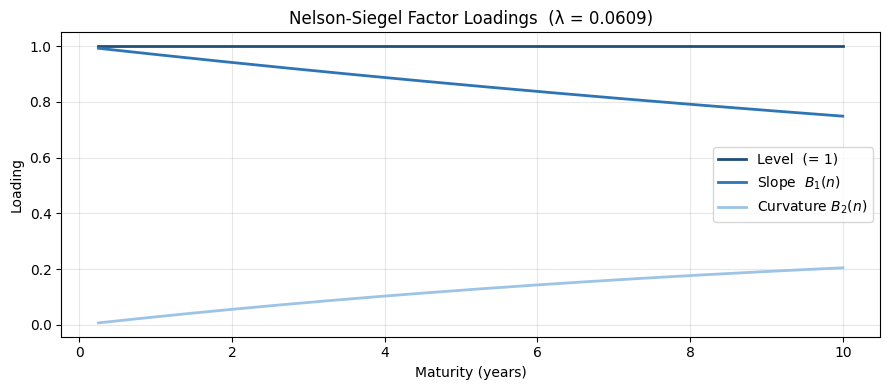

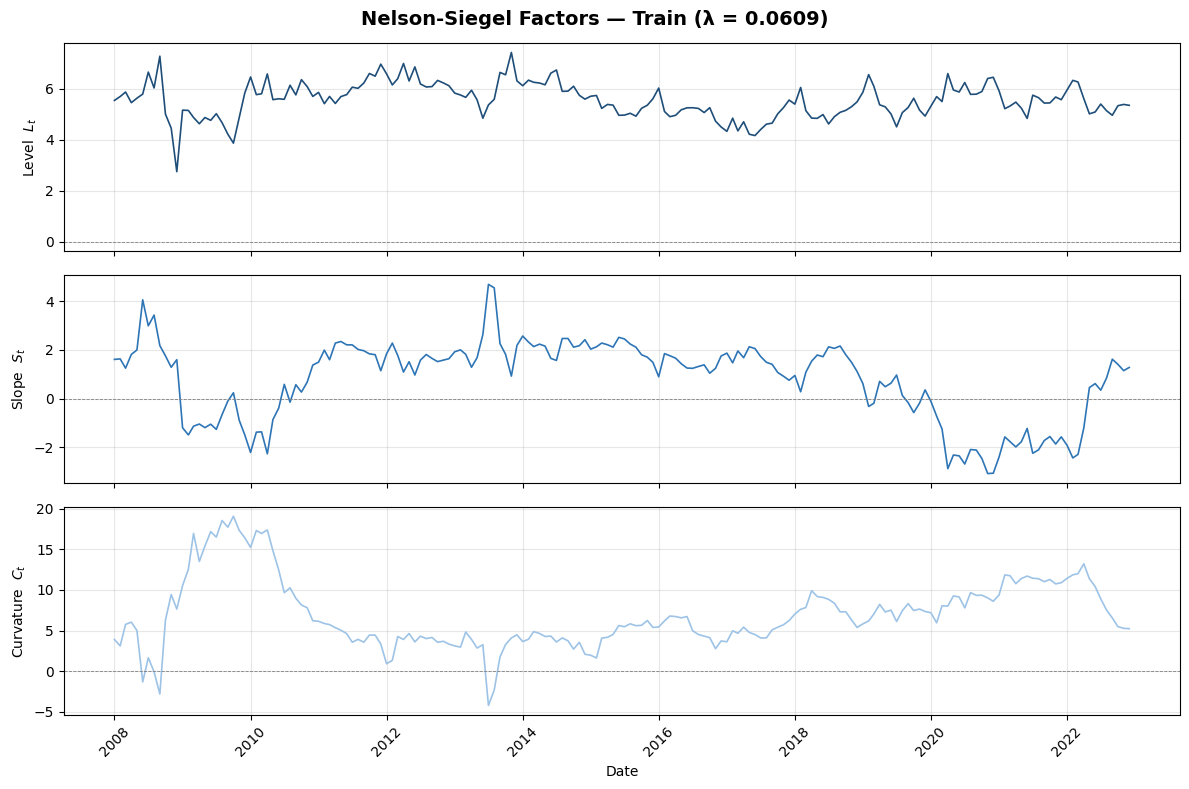

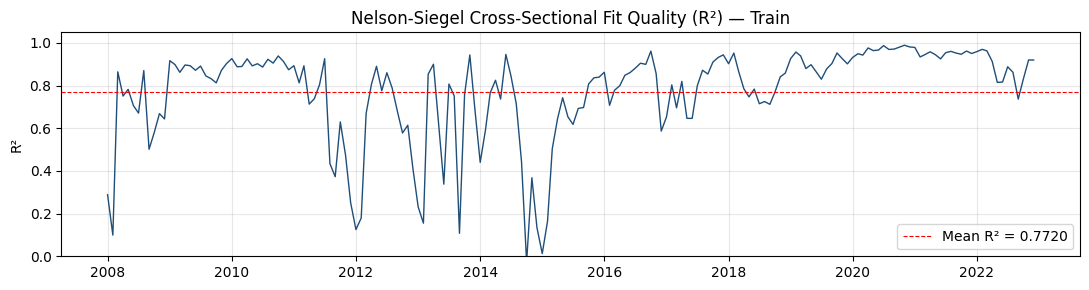

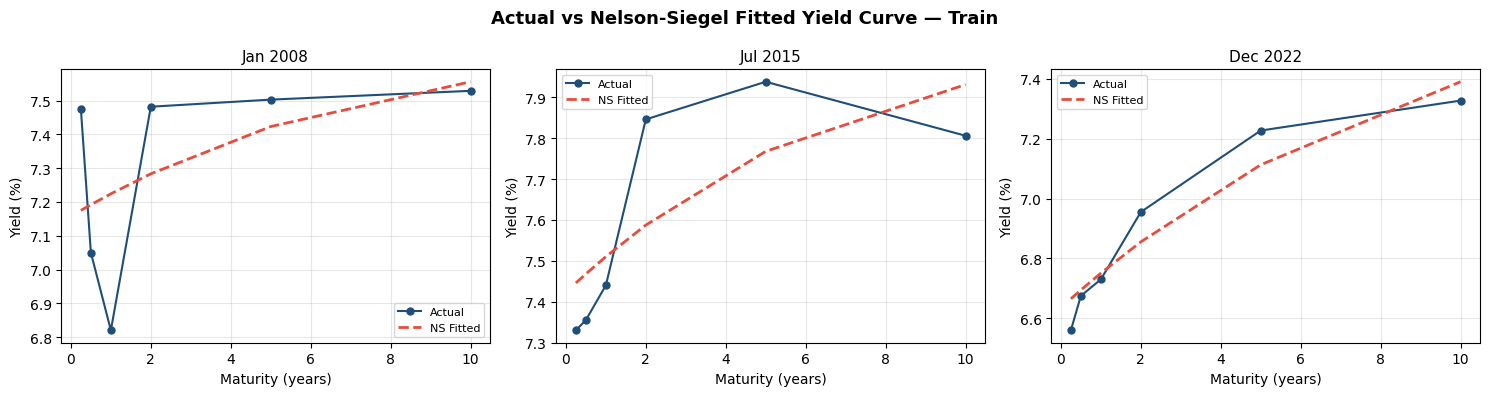


✅  factors_train ready for VAR estimation.
    Shape: (180, 4)  Columns: ['L', 'S', 'C', 'R2']


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 6 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 4: Generating plots")
print("=" * 60)

mats_fine = np.linspace(min(maturities), max(maturities), 300)
X_fine    = ns_loadings(mats_fine)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mats_fine, X_fine[:, 0], label="Level  (= 1)",       color="#1F4E79", linewidth=2)
ax.plot(mats_fine, X_fine[:, 1], label="Slope  $B_1(n)$",    color="#2E75B6", linewidth=2)
ax.plot(mats_fine, X_fine[:, 2], label="Curvature $B_2(n)$", color="#9DC3E6", linewidth=2)
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Loading")
ax.set_title(f"Nelson-Siegel Factor Loadings  (λ = {LAMBDA})")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Nelson-Siegel Factors — Train (λ = 0.0609)", fontsize=14, fontweight="bold")
colors = {"L": "#1F4E79", "S": "#2E75B6", "C": "#9DC3E6"}
labels = {"L": "Level  $L_t$", "S": "Slope  $S_t$", "C": "Curvature  $C_t$"}
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(factors_train.index, factors_train[col], color=colors[col], linewidth=1.2)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(labels[col], fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(factors_train.index, factors_train["R2"], color="#1F4E79", linewidth=1.0)
ax.axhline(factors_train["R2"].mean(), color="red", linestyle="--",
           linewidth=0.8, label=f"Mean R² = {factors_train['R2'].mean():.4f}")
ax.set_ylabel("R²"); ax.set_title("Nelson-Siegel Cross-Sectional Fit Quality (R²) — Train")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fitted_train = fitted_yields(factors_train, maturities)
mats         = np.asarray(maturities, dtype=float)
sample_dates = [yields_train.index[0],
                yields_train.index[len(yields_train) // 2],
                yields_train.index[-1]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, date in zip(axes, sample_dates):
    ax.plot(mats, yields_train.loc[date].values, "o-", color="#1F4E79",
            linewidth=1.5, markersize=5, label="Actual")
    ax.plot(mats, fitted_train.loc[date].values, "--", color="#E74C3C",
            linewidth=2, label="NS Fitted")
    ax.set_title(pd.Timestamp(date).strftime("%b %Y"), fontsize=11)
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.suptitle("Actual vs Nelson-Siegel Fitted Yield Curve — Train",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n✅  factors_train ready for VAR estimation.")
print(f"    Shape: {factors_train.shape}  Columns: {list(factors_train.columns)}")




  STEP 5: DNS VAR estimation on factors_train (BIC lag)

Lag order selection (AIC / BIC / FPE / HQIC):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       2.009       2.063       7.453       2.031
1      -3.033     -2.815*     0.04817      -2.945
2      -3.121      -2.740     0.04413     -2.966*
3      -3.158      -2.613     0.04254      -2.937
4     -3.199*      -2.490    0.04086*      -2.911
5      -3.183      -2.311     0.04154      -2.829
6      -3.136      -2.101     0.04359      -2.716
-------------------------------------------------

  AIC selects lag = 4   (kept as DNS-AIC benchmark)
  BIC selects lag = 1   ← MAIN model for forecasting

════════════════════════════════════════════════════════════
  MAIN MODEL — DNS VAR(1)  [BIC]
════════════════════════════════════════════════════════════
  Summary of Regression Results   
Model:                         VAR
Method:       

C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


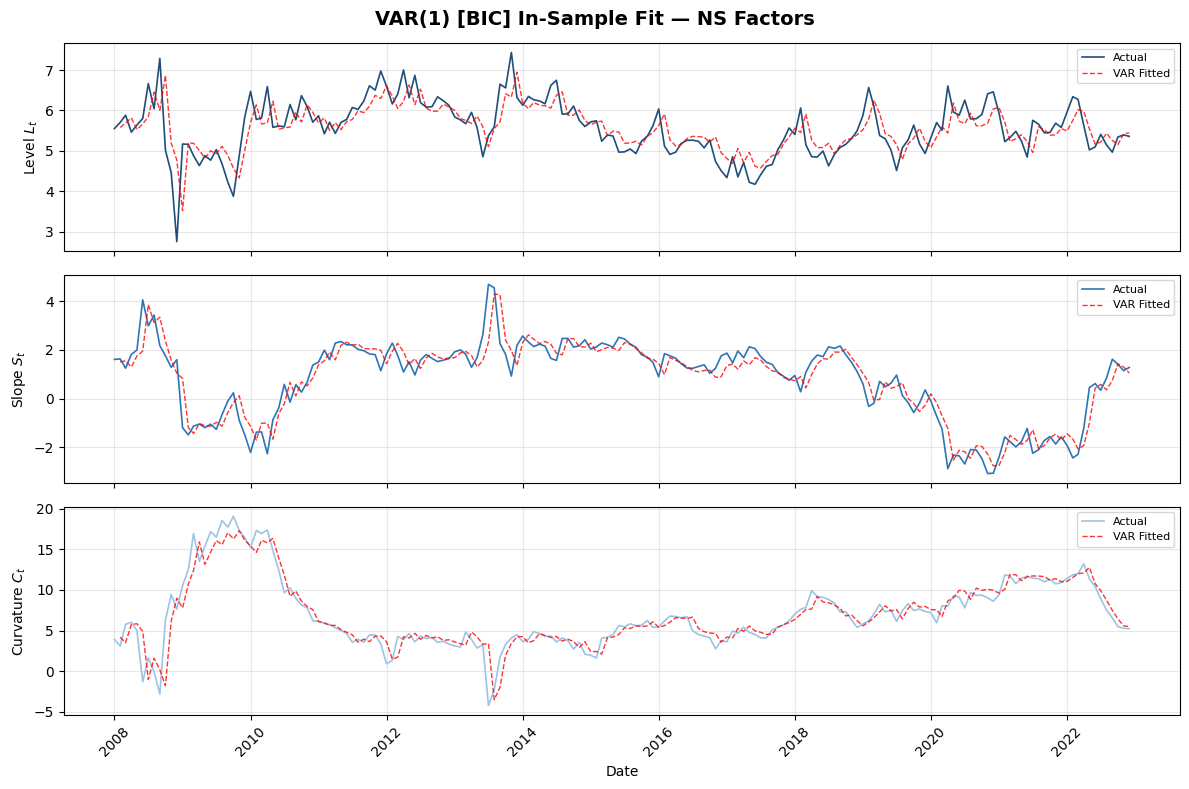

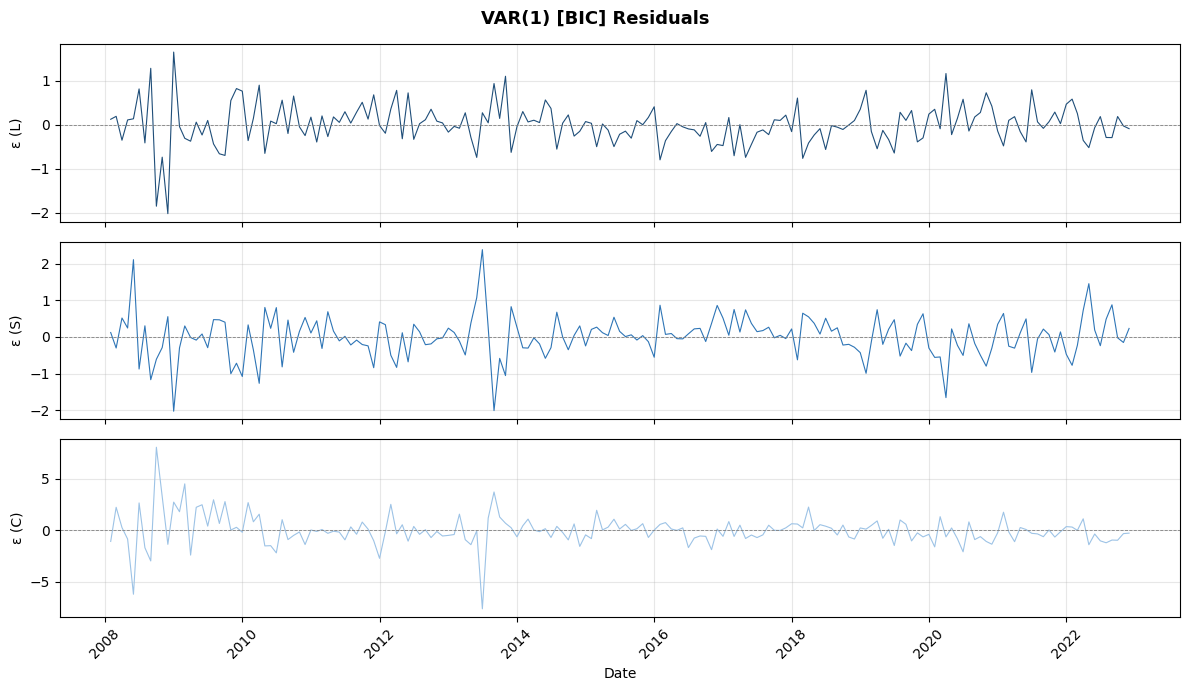

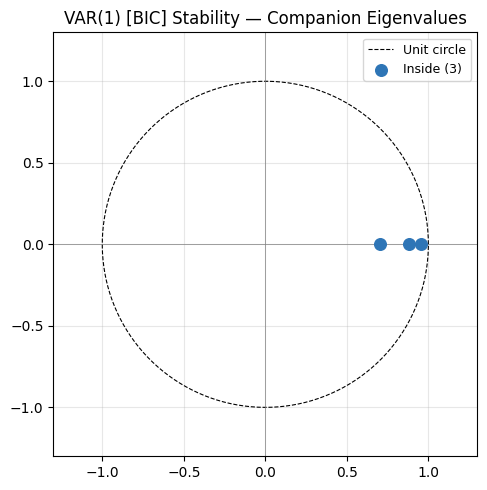


✅  DNS VAR done. var_result (BIC p=1), var_result_aic (AIC p=4).


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 7 — DNS VAR ESTIMATION  (BIC lag main; AIC kept as benchmark)
#
#      X_t = μ + A1·X_{t-1} + ... + Ap·X_{t-p} + ε_t,   X_t = [L,S,C]'
#
#  Stability: all eigenvalues of the FULL COMPANION MATRIX (K·p × K·p) must lie
#  inside the unit circle (checking only A1 is wrong for p > 1).
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.api import VAR

print("\n" + "=" * 60)
print("  STEP 5: DNS VAR estimation on factors_train (BIC lag)")
print("=" * 60)

var_data   = factors_train[["L", "S", "C"]].dropna()

# Lag selection on its own throwaway instance
lag_result = VAR(var_data).select_order(maxlags=6)
print("\nLag order selection (AIC / BIC / FPE / HQIC):")
print(lag_result.summary())

best_lag_aic = max(lag_result.aic, 1)   # AIC lag (benchmark)
best_lag     = max(lag_result.bic, 1)   # BIC lag (MAIN — floor at 1)
print(f"\n  AIC selects lag = {best_lag_aic}   (kept as DNS-AIC benchmark)")
print(f"  BIC selects lag = {best_lag}   ← MAIN model for forecasting")

# FIX: fit each lag on a FRESH VAR(...) instance so the two results never share
# mutable column-name metadata (that sharing caused the (4,3) vs (13,3) error).
var_result     = VAR(var_data).fit(maxlags=best_lag,     ic=None)   # BIC (main)
var_result_aic = VAR(var_data).fit(maxlags=best_lag_aic, ic=None)   # AIC (benchmark)

print("\n" + "═" * 60)
print(f"  MAIN MODEL — DNS VAR({best_lag})  [BIC]")
print("═" * 60)
print(var_result.summary())

# Robust intercept extraction (works regardless of params wrapping quirks)
mu = np.asarray(var_result.params.loc["const"]).ravel()
print("\nIntercept vector μ:")
print(pd.Series(mu, index=["L", "S", "C"]).round(6).to_string())

A = var_result.coefs[0]   # lag-1 matrix (descriptive only)
print(f"\nLag-1 coefficient matrix A1 (descriptive, VAR lag={best_lag}):")
print(pd.DataFrame(A, index=["L eq", "S eq", "C eq"],
                   columns=["L(-1)", "S(-1)", "C(-1)"]).round(4).to_string())

sigma = var_result.sigma_u
print("\nResidual covariance matrix Σ:")
print(pd.DataFrame(sigma, index=["L", "S", "C"],
                   columns=["L", "S", "C"]).round(6).to_string())


# ── Stability helpers (full companion matrix) ────────────────────────────────
def companion_matrix(var_res):
    """Full (K·p × K·p) companion matrix from a fitted VARResults."""
    coefs = var_res.coefs                       # (p, K, K)
    p, K, _ = coefs.shape
    F = np.zeros((K * p, K * p))
    F[:K, :] = np.hstack([coefs[i] for i in range(p)])
    if p > 1:
        F[K:, :-K] = np.eye(K * (p - 1))
    return F


def stability_report(var_res, label="VAR"):
    """Eigenvalues of companion matrix + verdict, cross-checked vs statsmodels."""
    F      = companion_matrix(var_res)
    eigs   = np.linalg.eigvals(F)
    order  = np.argsort(-np.abs(eigs))
    eigs   = eigs[order]
    moduli = np.abs(eigs)
    stable = bool(np.all(moduli < 1.0))

    p, K = var_res.k_ar, var_res.neqs
    print("\n" + "─" * 62)
    print(f"Stability Check — {label}   (K = {K} variables, p = {p} lags)")
    print(f"Companion matrix: {K*p}×{K*p}  →  {K*p} eigenvalues")
    print("─" * 62)
    for i, (ev, mod) in enumerate(zip(eigs, moduli)):
        flag = "✅ inside unit circle" if mod < 1 else "❌ OUTSIDE unit circle"
        print(f"  λ{i+1:2d} = {ev.real:+.6f}{ev.imag:+.6f}j   |λ| = {mod:.6f}  {flag}")
    print(f"\n  Largest |λ| = {moduli[0]:.6f}")
    if stable and moduli[0] > 0.97:
        print("  ⚠️  Near-unit root: stable but highly persistent (normal for the")
        print("      level factor; long-horizon forecasts mean-revert slowly).")
    print(f"\n  {label} is {'STABLE ✅' if stable else 'UNSTABLE ❌'}")
    sm_stable = var_res.is_stable()
    print(f"  Cross-check: statsmodels is_stable() = {sm_stable}  "
          f"{'✅' if sm_stable == stable else '❌ MISMATCH!'}")
    print("─" * 62)
    assert np.allclose(np.sort(moduli), np.sort(1.0 / np.abs(var_res.roots))), \
        "Companion eigenvalues don't match 1/|statsmodels roots|"
    return eigs, moduli, stable


eigenvalues, moduli, is_stable = stability_report(var_result, label=f"DNS VAR({best_lag}) [BIC]")
eigenvalues_aic, moduli_aic, is_stable_aic = stability_report(
    var_result_aic, label=f"DNS VAR({best_lag_aic}) [AIC]")

print("\n  AIC vs BIC model structure (DNS):")
print(pd.DataFrame({
    f"BIC (p={best_lag})": {
        "total params": var_result.params.size, "obs used": var_result.nobs,
        "max |λ|": round(moduli[0], 4), "stable": is_stable},
    f"AIC (p={best_lag_aic})": {
        "total params": var_result_aic.params.size, "obs used": var_result_aic.nobs,
        "max |λ|": round(moduli_aic[0], 4), "stable": is_stable_aic},
}).to_string())

# ── Fit / residual / stability plots (BIC model) ─────────────────────────────
factor_colors = {"L": "#1F4E79", "S": "#2E75B6", "C": "#9DC3E6"}
factor_labels = {"L": "Level $L_t$", "S": "Slope $S_t$", "C": "Curvature $C_t$"}

var_fitted = var_result.fittedvalues
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"VAR({best_lag}) [BIC] In-Sample Fit — NS Factors", fontsize=14, fontweight="bold")
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(var_data.index, var_data[col], color=factor_colors[col], linewidth=1.2, label="Actual")
    ax.plot(var_fitted.index, var_fitted[col], color="red", linewidth=1.0,
            linestyle="--", label="VAR Fitted", alpha=0.8)
    ax.set_ylabel(factor_labels[col], fontsize=10); ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

var_resid = var_result.resid
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f"VAR({best_lag}) [BIC] Residuals", fontsize=13, fontweight="bold")
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(var_resid.index, var_resid[col], color=factor_colors[col], linewidth=0.8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(f"ε ({col})", fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8, label="Unit circle")
inside = moduli < 1
ax.scatter(eigenvalues[inside].real, eigenvalues[inside].imag, color="#2E75B6",
           zorder=5, s=70, label=f"Inside ({inside.sum()})")
if (~inside).any():
    ax.scatter(eigenvalues[~inside].real, eigenvalues[~inside].imag, color="#E74C3C",
               zorder=6, s=90, marker="X", label=f"OUTSIDE ({(~inside).sum()})")
lim = max(1.3, moduli.max() * 1.15)
ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_title(f"VAR({best_lag}) [BIC] Stability — Companion Eigenvalues")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n✅  DNS VAR done. var_result (BIC p={best_lag}), "
      f"var_result_aic (AIC p={best_lag_aic}).")


  STEP 6: Loading macro data & PCA
  Date parsed with format: %Y-%m-%d

  Macro raw shape   : (248, 49)
  Macro date range  : 2005-01-31  →  2025-08-31
  Macro columns     : ['FOREX', 'CAPITAL_ACCOUNT', 'NET_BANK_RESERVES', 'CREDIT_TO_GOV', 'LOANS_ADVANCES_FROM_RBI', 'DOMESTIC_CREDIT', 'LONG_TERM_TIME_DEPOSIT', 'WPI_INFLATION', 'REPO_RATE', 'IN10Y', 'EURINR', 'GBPINR', 'GOLD', 'IN01Y', 'IN03MY', 'IN05Y', 'IN06MY', 'ININBR', 'NIFTY', 'SPX', 'UKOIL', 'US10Y', 'USDINR', 'VIX', '1Y', '2Y', '3M', '6M', '9M', 'spread_3M_6M', 'spread_3M_9M', 'spread_3M_1Y', 'spread_3M_2Y', 'spread_6M_9M', 'spread_6M_1Y', 'spread_6M_2Y', 'spread_9M_1Y', 'spread_9M_2Y', 'spread_1Y_2Y', 'fwd_3M_6M', 'fwd_3M_9M', 'fwd_3M_1Y', 'fwd_3M_2Y', 'fwd_6M_9M', 'fwd_6M_1Y', 'fwd_6M_2Y', 'fwd_9M_1Y', 'fwd_9M_2Y', 'fwd_1Y_2Y']

  After date snap   : 2005-01-01  →  2025-08-01

  Macro train shape : (180, 49)
  Macro after cleaning: (180, 49)

  ADF Test & Stationarity Transformations:
  Variable                              

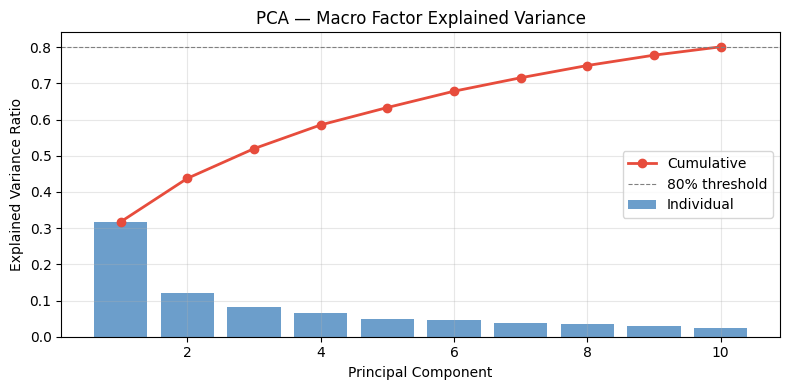

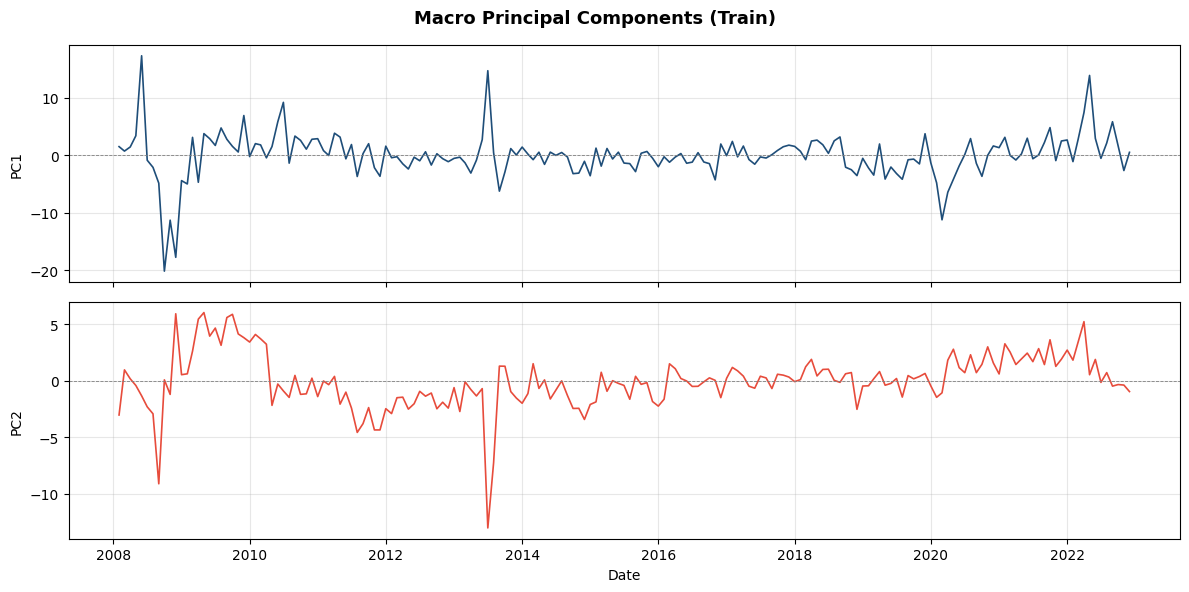

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 8 — MACRO FACTOR EXTRACTION (PCA)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller

print("\n" + "=" * 60)
print("  STEP 6: Loading macro data & PCA")
print("=" * 60)

macro_raw = pd.read_csv(macro_path)
macro_raw.columns = macro_raw.columns.str.strip()
date_col = next(c for c in macro_raw.columns if c.lower() == "date")

for fmt in ("%d-%m-%Y", "%Y-%m-%d", "%m/%d/%Y", "%b %d, %Y"):
    try:
        macro_raw[date_col] = pd.to_datetime(macro_raw[date_col], format=fmt, errors="raise")
        print(f"  Date parsed with format: {fmt}")
        break
    except Exception:
        continue
else:
    macro_raw[date_col] = pd.to_datetime(macro_raw[date_col], dayfirst=True, errors="coerce")
    print("  Date parsed with dayfirst=True")

macro_raw = macro_raw.rename(columns={date_col: "Date"}).set_index("Date").sort_index()
macro_raw = macro_raw.apply(pd.to_numeric, errors="coerce")
print(f"\n  Macro raw shape   : {macro_raw.shape}")
print(f"  Macro date range  : {macro_raw.index[0].date()}  →  {macro_raw.index[-1].date()}")
print(f"  Macro columns     : {list(macro_raw.columns)}")

# Snap to month-start to match yields_train index
macro_raw.index = macro_raw.index.to_period("M").to_timestamp("s")
print(f"\n  After date snap   : {macro_raw.index[0].date()}  →  {macro_raw.index[-1].date()}")

train_start, train_end = yields_train.index[0], yields_train.index[-1]
macro_train = macro_raw.loc[(macro_raw.index >= train_start) &
                            (macro_raw.index <= train_end)].copy()
print(f"\n  Macro train shape : {macro_train.shape}")

nan_pct = macro_train.isna().mean()
drop_cols = nan_pct[nan_pct > 0.2].index.tolist()
if drop_cols:
    print(f"  Dropping columns with >20% NaN: {drop_cols}")
    macro_train = macro_train.drop(columns=drop_cols)
macro_train = macro_train.ffill().dropna(axis=1)
print(f"  Macro after cleaning: {macro_train.shape}")


def make_stationary(df, pvalue_threshold=0.05):
    """ADF per column; log-return if strictly positive, else first-diff."""
    result, translog = {}, {}
    for col in df.columns:
        series = df[col].dropna()
        pval   = adfuller(series, autolag="AIC")[1]
        if pval <= pvalue_threshold:
            result[col] = df[col]; translog[col] = "none"
        else:
            if (series > 0).all():
                transformed = np.log(df[col]).diff(); translog[col] = "log_return"
            else:
                transformed = df[col].diff(); translog[col] = "first_diff"
            result[col] = transformed
            pval_after = adfuller(transformed.dropna(), autolag="AIC")[1]
            status = "✅" if pval_after <= pvalue_threshold else "⚠️ still non-stationary"
            print(f"  {col:35s}  p={pval:.3f} → {translog[col]:12s}  after: p={pval_after:.3f} {status}")
    return pd.DataFrame(result, index=df.index).dropna(), translog


print("\n  ADF Test & Stationarity Transformations:")
print(f"  {'Variable':35s}  {'ADF p-val':>10}  {'Transform':>12}  After")
print("  " + "─" * 75)
macro_stationary, translog = make_stationary(macro_train)
print(f"\n  Already stationary : {sum(v=='none' for v in translog.values())}")
print(f"  Log return         : {sum(v=='log_return' for v in translog.values())}")
print(f"  First difference   : {sum(v=='first_diff' for v in translog.values())}")
print(f"  Shape after        : {macro_stationary.shape}")

scaler       = StandardScaler()
macro_scaled = scaler.fit_transform(macro_stationary)
macro_train_orig = macro_train.copy()
macro_train      = macro_stationary

pca = PCA(n_components=min(10, macro_scaled.shape[1]))
pca.fit(macro_scaled)
explained      = pca.explained_variance_ratio_
cumulative_exp = np.cumsum(explained)
print("\n  PCA Explained Variance:")
for i, (ev, cv) in enumerate(zip(explained, cumulative_exp)):
    print(f"    PC{i+1}: {ev:.4f}  (cumulative: {cv:.4f})")

pca2    = PCA(n_components=2)
pc_vals = pca2.fit_transform(macro_scaled)
macro_pca = pd.DataFrame(pc_vals, index=macro_train.index, columns=["PC1", "PC2"])
print(f"\n  PC1 & PC2 extracted. Shape: {macro_pca.shape}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained) + 1), explained, color="#2E75B6", alpha=0.7, label="Individual")
ax.plot(range(1, len(explained) + 1), cumulative_exp, "o-", color="#E74C3C", linewidth=2, label="Cumulative")
ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.8, label="80% threshold")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Macro Factor Explained Variance"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Macro Principal Components (Train)", fontsize=13, fontweight="bold")
for ax, col, color in zip(axes, ["PC1", "PC2"], ["#1F4E79", "#E74C3C"]):
    ax.plot(macro_pca.index, macro_pca[col], color=color, linewidth=1.2)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(col, fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.tight_layout(); plt.show()




  STEP 7: Building FADNS state vector & re-estimating VAR (BIC)

  Common dates: 179  (2008-02-01 → 2022-12-01)
  State vector shape: (179, 5)  Columns: ['PC1', 'PC2', 'L', 'S', 'C']
                PC1     PC2       L       S       C
Date                                               
2008-02-01   1.5043 -3.0249  5.7030  1.6295  3.1226
2008-03-01   0.7273  0.9746  5.8813  1.2486  5.7661
2008-04-01   1.4468  0.1823  5.4628  1.8145  6.0376
2008-05-01   3.3923 -0.4050  5.6390  1.9945  5.0062
2008-06-01  17.3008 -1.3226  5.7996  4.0584 -1.2961

  Lag order selection (FADNS — 5 variables):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       5.248       5.339       190.2       5.285
1      -2.854     -2.307*     0.05762     -2.632*
2      -2.869      -1.866     0.05682      -2.462
3      -2.992      -1.533     0.05034      -2.400
4     -3.136*      -1.223    0.04370*      -2.360
5     

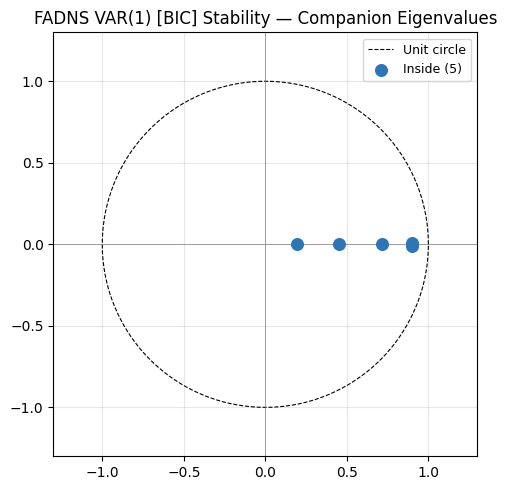

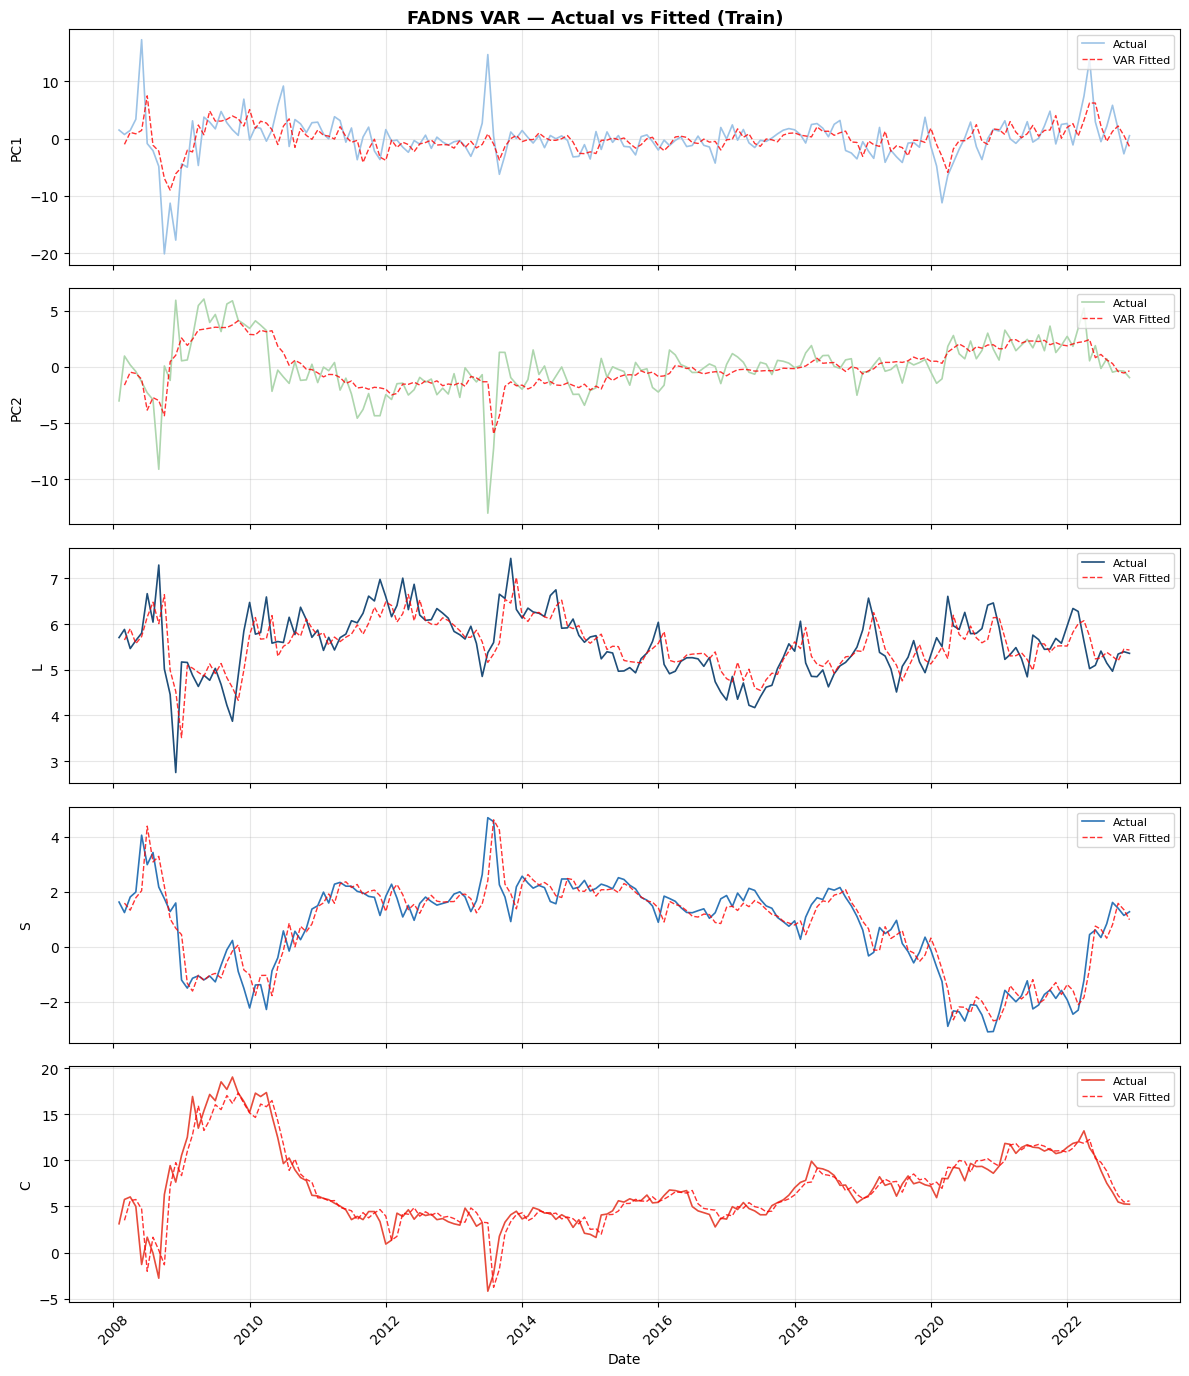


✅  FADNS VAR done (BIC, p=1).


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 9 — FADNS STATE VECTOR & VAR RE-ESTIMATION  (BIC lag)
#  X_t = [PC1, PC2, L, S, C]
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 7: Building FADNS state vector & re-estimating VAR (BIC)")
print("=" * 60)

common_idx = factors_train.index.intersection(macro_pca.index)
print(f"\n  Common dates: {len(common_idx)}  "
      f"({common_idx[0].date()} → {common_idx[-1].date()})")

state_train = pd.concat([
    macro_pca.loc[common_idx, ["PC1", "PC2"]],
    factors_train.loc[common_idx, ["L", "S", "C"]]
], axis=1).dropna()
print(f"  State vector shape: {state_train.shape}  Columns: {list(state_train.columns)}")
print(state_train.head().round(4))

# Lag selection on its own throwaway instance
fadns_lag_result = VAR(state_train).select_order(maxlags=6)
print("\n  Lag order selection (FADNS — 5 variables):")
print(fadns_lag_result.summary())

fadns_best_lag_aic = max(fadns_lag_result.aic, 1)
fadns_best_lag     = max(fadns_lag_result.bic, 1)   # BIC — used for forecasting
print(f"\n  AIC selects lag = {fadns_best_lag_aic}")
print(f"  BIC selects lag = {fadns_best_lag}   ← used for forecasting")

# FIX: fresh instance for the fit (separate from the select_order instance)
fadns_var_result = VAR(state_train).fit(maxlags=fadns_best_lag, ic=None)
print(fadns_var_result.summary())

A_fadns = fadns_var_result.coefs[0]
print(f"\nLag-1 coefficient matrix A1 (descriptive, FADNS lag={fadns_best_lag}):")
print(pd.DataFrame(A_fadns,
                   index=[f"{v} eq" for v in state_train.columns],
                   columns=[f"{v}(-1)" for v in state_train.columns]).round(4).to_string())

eigenvalues_fadns, moduli_fadns, is_stable_fadns = stability_report(
    fadns_var_result, label=f"FADNS VAR({fadns_best_lag}) [BIC]")

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8, label="Unit circle")
inside_f = moduli_fadns < 1
ax.scatter(eigenvalues_fadns[inside_f].real, eigenvalues_fadns[inside_f].imag,
           color="#2E75B6", zorder=5, s=70, label=f"Inside ({inside_f.sum()})")
if (~inside_f).any():
    ax.scatter(eigenvalues_fadns[~inside_f].real, eigenvalues_fadns[~inside_f].imag,
               color="#E74C3C", zorder=6, s=90, marker="X", label=f"OUTSIDE ({(~inside_f).sum()})")
lim = max(1.3, moduli_fadns.max() * 1.15)
ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_title(f"FADNS VAR({fadns_best_lag}) [BIC] Stability — Companion Eigenvalues")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

fadns_fitted = fadns_var_result.fittedvalues
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
fig.suptitle("FADNS VAR — Actual vs Fitted (Train)", fontsize=13, fontweight="bold")
plot_colors = ["#9DC3E6", "#AED6AE", "#1F4E79", "#2E75B6", "#E74C3C"]
for ax, col, color in zip(axes, state_train.columns, plot_colors):
    ax.plot(state_train.index, state_train[col], color=color, linewidth=1.2, label="Actual")
    ax.plot(fadns_fitted.index, fadns_fitted[col], color="red", linewidth=1.0,
            linestyle="--", alpha=0.8, label="VAR Fitted")
    ax.set_ylabel(col, fontsize=10); ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"\n✅  FADNS VAR done (BIC, p={fadns_best_lag}).")


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 10 — FORECASTING  (static + expanding window, h = 3, 6, 12)
#
#  Models produced:
#    RW            random walk (ŷ_{t+h} = ŷ_t)
#    AR(1)         per-maturity AR(1)
#    DNS-BIC       VAR[L,S,C] BIC lag — static (train-only fit)
#    DNS-BIC-exp   VAR[L,S,C] BIC lag — EXPANDING (refit each origin)
#    DNS-AIC-exp   VAR[L,S,C] AIC lag — EXPANDING (AIC vs BIC check, real-time)
#    FADNS         VAR[PC1,PC2,L,S,C] BIC lag — static
#    FADNS-exp     VAR[PC1,PC2,L,S,C] BIC lag — EXPANDING
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ar_model import AutoReg

print("\n" + "=" * 60)
print("  STEP 8: Forecasting (static + expanding window)")
print("=" * 60)

HORIZONS   = [3, 6, 12]
MAX_H      = max(HORIZONS)
mats_array = np.asarray(maturities, dtype=float)
REFIT_LAG  = False   # expanding window: False = fixed train lag; True = re-select BIC per window

# ── Test macro factors (TRAIN-fitted scaler & PCA — no look-ahead) ───────────
macro_test = macro_raw.loc[(macro_raw.index >= yields_test.index[0]) &
                           (macro_raw.index <= yields_test.index[-1])].copy()
macro_test = macro_test.ffill()[macro_train_orig.columns]

macro_test_stat = {}
for col in macro_train.columns:
    t = translog[col]
    if   t == "none":       macro_test_stat[col] = macro_test[col]
    elif t == "log_return": macro_test_stat[col] = np.log(macro_test[col]).diff()
    elif t == "first_diff": macro_test_stat[col] = macro_test[col].diff()
macro_test_stat   = pd.DataFrame(macro_test_stat, index=macro_test.index).dropna()
macro_test_scaled = scaler.transform(macro_test_stat)
macro_pca_test    = pd.DataFrame(pca2.transform(macro_test_scaled),
                                 index=macro_test_stat.index, columns=["PC1", "PC2"])

factors_test = extract_factors(yields_test, maturities)

state_test_common = pd.concat([macro_pca_test, factors_test[["L", "S", "C"]]],
                              axis=1).dropna()
state_all = pd.concat([state_train, state_test_common]).sort_index()

factors_all = pd.concat([factors_train[["L", "S", "C"]],
                         factors_test[["L", "S", "C"]]]).sort_index().dropna()

print(f"  Test state vector : {state_test_common.shape}  "
      f"({state_test_common.index[0].date()} → {state_test_common.index[-1].date()})")


def reconstruct_curve(L, S, C, mats=mats_array, lam=LAMBDA):
    X = ns_loadings(mats, lam)
    return np.array([L, S, C]) @ X.T


# ── STATIC forecaster: one fit on train, applied at every origin ─────────────
def static_var_forecasts(fitted_res, full_data, origin_dates, lag, lsc_pos):
    """Forecast h ahead from each origin using a model already fit on train."""
    iL, iS, iC = lsc_pos
    out = {h: {} for h in HORIZONS}
    for t_date in origin_dates:
        pos = full_data.index.get_loc(t_date)
        if pos < lag:
            continue
        init = full_data.iloc[pos - lag + 1: pos + 1].values
        fc   = fitted_res.forecast(init, steps=MAX_H)
        for h in HORIZONS:
            v = fc[h - 1]
            out[h][t_date] = reconstruct_curve(v[iL], v[iS], v[iC])
    for h in HORIZONS:
        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
    return out


# ── EXPANDING forecaster: refit VAR on all data up to each origin ────────────
def expanding_var_forecasts(full_data, origin_dates, lag, lsc_pos,
                            label="", refit_lag=False, maxlags_cap=6):
    """
    Recursive expanding window. At each origin t, refit VAR on full_data[:t]
    (everything up to and including t — no look-ahead), forecast h ahead.
    A FRESH VAR(window) is built each iteration, so no shared-state issues.
    Refits ONCE per origin (model doesn't depend on h); forecasts MAX_H, slices.
    """
    iL, iS, iC = lsc_pos
    out = {h: {} for h in HORIZONS}
    n_fit = n_skip = 0
    for t_date in origin_dates:
        try:
            pos = full_data.index.get_loc(t_date)
        except KeyError:
            n_skip += 1; continue
        window = full_data.iloc[:pos + 1]
        if refit_lag:
            try:
                sel = VAR(window).select_order(maxlags=min(maxlags_cap, len(window) // 4))
                this_lag = max(sel.bic, 1)
            except Exception:
                this_lag = lag
        else:
            this_lag = lag
        if len(window) < this_lag + 3:
            n_skip += 1; continue
        try:
            res  = VAR(window).fit(maxlags=this_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)
        except Exception:
            n_skip += 1; continue
        n_fit += 1
        for h in HORIZONS:
            v = fc[h - 1]
            out[h][t_date] = reconstruct_curve(v[iL], v[iS], v[iC])
    for h in HORIZONS:
        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
    print(f"  {label:12s}: refit {n_fit} windows, skipped {n_skip}  "
          f"(lag {'re-selected' if refit_lag else f'fixed={lag}'})")
    return out


# ── DNS-BIC: static + expanding ──────────────────────────────────────────────
print("\n  DNS-BIC static + expanding...")
dns_forecasts     = static_var_forecasts(var_result, factors_all, factors_test.index,
                                         best_lag, (0, 1, 2))
dns_forecasts_exp = expanding_var_forecasts(factors_all, factors_test.index,
                                            best_lag, (0, 1, 2),
                                            label="DNS-BIC", refit_lag=REFIT_LAG)

# ── DNS-AIC: expanding (real-time AIC vs BIC check) ──────────────────────────
print("  DNS-AIC expanding...")
dns_forecasts_aic_exp = expanding_var_forecasts(factors_all, factors_test.index,
                                                best_lag_aic, (0, 1, 2),
                                                label="DNS-AIC", refit_lag=REFIT_LAG)

# ── FADNS: static + expanding ────────────────────────────────────────────────
print("  FADNS static + expanding...")
fadns_forecasts     = static_var_forecasts(fadns_var_result, state_all,
                                           state_test_common.index,
                                           fadns_best_lag, (2, 3, 4))
fadns_forecasts_exp = expanding_var_forecasts(state_all, state_test_common.index,
                                              fadns_best_lag, (2, 3, 4),
                                              label="FADNS", refit_lag=REFIT_LAG)

# ── RW benchmark ─────────────────────────────────────────────────────────────
rw_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        if t_date in yields_test.index:
            rw_forecasts[h][t_date] = yields_test.loc[t_date].values
        else:
            pos = min(yields_test.index.searchsorted(t_date), len(yields_test) - 1)
            rw_forecasts[h][t_date] = yields_test.iloc[pos].values
    rw_forecasts[h] = pd.DataFrame(rw_forecasts[h], index=mats_array).T
    rw_forecasts[h].index.name = "Date"

# ── AR(1) per maturity benchmark ─────────────────────────────────────────────
ar_models = {col: AutoReg(yields_train[col].dropna(), lags=1).fit()
             for col in yields_train.columns}
ar_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        yhat = []
        for col in yields_train.columns:
            if t_date in yields_test.index:
                last_val = yields_test.loc[t_date, col]
            else:
                pos = min(yields_test.index.searchsorted(t_date), len(yields_test) - 1)
                last_val = yields_test.iloc[pos][col]
            # FIX: .iloc positional access (params is a label-indexed Series on pandas 2.x)
            phi0, phi1 = ar_models[col].params.iloc[0], ar_models[col].params.iloc[1]
            yhat.append(phi0 * (1 - phi1**h) / (1 - phi1 + 1e-12) + phi1**h * last_val)
        ar_forecasts[h][t_date] = np.array(yhat)
    ar_forecasts[h] = pd.DataFrame(ar_forecasts[h], index=mats_array).T
    ar_forecasts[h].index.name = "Date"

print("\n  Benchmarks (RW, AR(1)) done.")
for h in HORIZONS:
    print(f"    h={h:2d}: DNS-BIC stat {dns_forecasts[h].shape} / exp {dns_forecasts_exp[h].shape}, "
          f"FADNS stat {fadns_forecasts[h].shape} / exp {fadns_forecasts_exp[h].shape}")


# ── Align actuals at t+h ─────────────────────────────────────────────────────
def get_actual_at_horizon(forecast_df, yields_test, h):
    rows = {}
    for t_date in forecast_df.index:
        future  = t_date + pd.DateOffset(months=h)
        diffs   = np.abs((yields_test.index - future).days)
        nearest = yields_test.index[diffs.argmin()]
        if diffs.min() <= 45:
            rows[t_date] = yields_test.loc[nearest].values
    return pd.DataFrame(rows, index=mats_array).T


actual_h = {}
for h in HORIZONS:
    actual_h[h] = get_actual_at_horizon(fadns_forecasts[h], yields_test, h)
    print(f"  Actuals at h={h:2d}: {actual_h[h].shape}")



  STEP 8: Forecasting (static + expanding window)
  Test state vector : (29, 5)  (2023-02-01 → 2025-06-01)

  DNS-BIC static + expanding...


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmod

  DNS-BIC     : refit 30 windows, skipped 0  (lag fixed=1)
  DNS-AIC expanding...
  DNS-AIC     : refit 30 windows, skipped 0  (lag fixed=4)
  FADNS static + expanding...


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmod

  FADNS       : refit 29 windows, skipped 0  (lag fixed=1)

  Benchmarks (RW, AR(1)) done.
    h= 3: DNS-BIC stat (30, 6) / exp (30, 6), FADNS stat (29, 6) / exp (29, 6)
    h= 6: DNS-BIC stat (30, 6) / exp (30, 6), FADNS stat (29, 6) / exp (29, 6)
    h=12: DNS-BIC stat (30, 6) / exp (30, 6), FADNS stat (29, 6) / exp (29, 6)
  Actuals at h= 3: (27, 6)
  Actuals at h= 6: (24, 6)
  Actuals at h=12: (18, 6)



  STEP 9: Evaluation

───────────────────────────────────────────────────────
  Horizon h = 3 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.2869  0.2795   0.2321       0.2334       0.2537  0.2616     0.2666
0.5Y   0.2913  0.2860   0.2525       0.2593       0.2683  0.2861     0.2927
1.0Y   0.3259  0.3211   0.2905       0.3018       0.2922  0.3277     0.3345
2.0Y   0.3230  0.3234   0.2988       0.2979       0.3273  0.2955     0.2964
5.0Y   0.2873  0.3164   0.2703       0.2668       0.2449  0.3046     0.2943
10.0Y  0.2083  0.2596   0.3482       0.3191       0.2480  0.3907     0.3549

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.1954  0.1837   0.1901       0.1900       0.2179  0.2069     0.2113
0.5Y   0.2224  0.2174   0.2090       0.2115       0.2223  0.2357     0.2404
1.0Y   0.2722  0.2665   0.2389       0.2462   

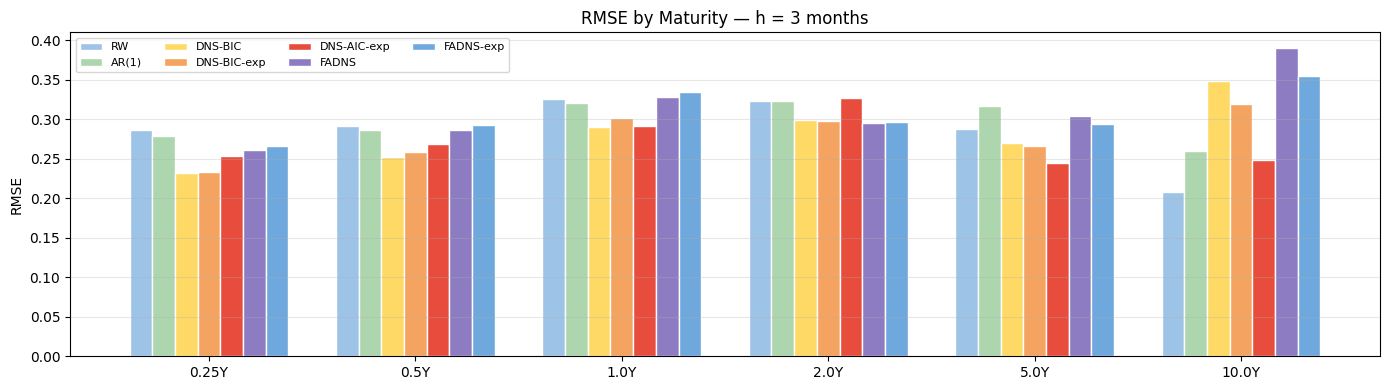


───────────────────────────────────────────────────────
  Horizon h = 6 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.4368  0.4049   0.3165       0.3211       0.3860  0.3398     0.3531
0.5Y   0.4284  0.4037   0.3093       0.3205       0.3685  0.3545     0.3709
1.0Y   0.4330  0.4158   0.3192       0.3373       0.3504  0.3893     0.4073
2.0Y   0.4362  0.4270   0.3652       0.3690       0.4244  0.3883     0.3946
5.0Y   0.3742  0.4349   0.3476       0.3436       0.2949  0.4070     0.3987
10.0Y  0.2799  0.3833   0.5084       0.4699       0.3408  0.5574     0.5156

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.2832  0.2575   0.2603       0.2466       0.3422  0.2640     0.2681
0.5Y   0.3012  0.2715   0.2338       0.2261       0.3166  0.2654     0.2783
1.0Y   0.3471  0.3208   0.2277       0.2448       0.2661  0.3096    

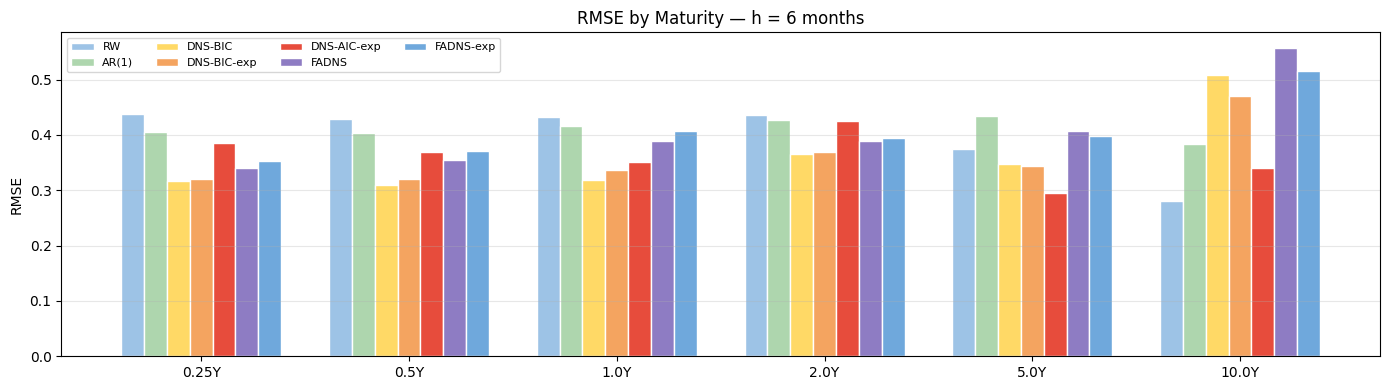


───────────────────────────────────────────────────────
  Horizon h = 12 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.5736  0.4746   0.4209       0.4365       0.4862  0.4475     0.4692
0.5Y   0.6199  0.5234   0.4278       0.4490       0.4700  0.4629     0.4886
1.0Y   0.6765  0.5817   0.4576       0.4840       0.4584  0.5013     0.5301
2.0Y   0.6675  0.5905   0.4355       0.4519       0.4598  0.4671     0.4857
5.0Y   0.6121  0.6678   0.5285       0.5332       0.4309  0.5747     0.5796
10.0Y  0.4786  0.6127   0.7650       0.7394       0.6067  0.8007     0.7767

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.4006  0.3317   0.3532       0.3535       0.4398  0.3507     0.3586
0.5Y   0.4655  0.3738   0.3312       0.3475       0.4072  0.3534     0.3642
1.0Y   0.5416  0.4434   0.3567       0.3825       0.3664  0.3870   

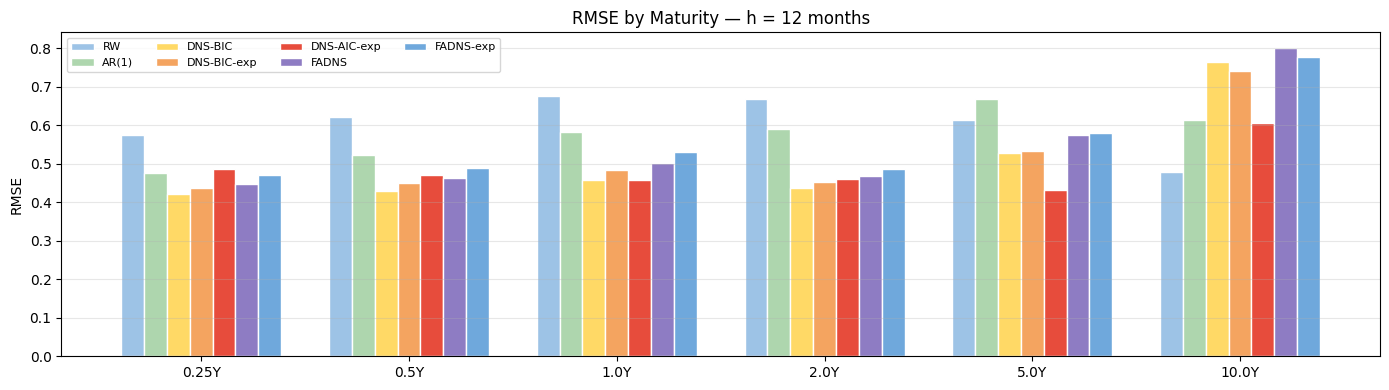


  SUMMARY — Average RMSE across maturities (lower = better)
                h=3     h=6    h=12
RW           0.2871  0.3981  0.6047
AR(1)        0.2977  0.4116  0.5751
DNS-BIC      0.2821  0.3610  0.5059
DNS-BIC-exp  0.2797  0.3602  0.5157
DNS-AIC-exp  0.2724  0.3608  0.4853
FADNS        0.3110  0.4060  0.5424
FADNS-exp    0.3066  0.4067  0.5550

  STATIC vs EXPANDING (Δ = static − expanding; +ve → expanding wins):
    h= 3m  DNS-BIC Δ=+0.0024 → expanding ✅   |  FADNS Δ=+0.0045 → expanding ✅
    h= 6m  DNS-BIC Δ=+0.0008 → expanding ✅   |  FADNS Δ=-0.0006 → static ✅
    h=12m  DNS-BIC Δ=-0.0098 → static ✅   |  FADNS Δ=-0.0126 → static ✅

  AIC vs BIC (expanding, DNS):
    h= 3m  AIC=0.2724 | BIC=0.2797 → AIC ✅
    h= 6m  AIC=0.3608 | BIC=0.3602 → BIC ✅
    h=12m  AIC=0.4853 | BIC=0.5157 → AIC ✅

  FADNS vs DNS vs RW (expanding where available):
    h= 3m  RW=0.2872 | DNS-exp=0.2797 | FADNS-exp=0.3066
    h= 6m  RW=0.3981 | DNS-exp=0.3602 | FADNS-exp=0.4067
    h=12m  RW=0.6047 | DNS-ex

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11 — EVALUATION  (RMSE / MAE; AIC-vs-BIC + static-vs-expanding)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 9: Evaluation")
print("=" * 60)

def compute_metrics(forecast_df, actual_df):
    common = forecast_df.index.intersection(actual_df.index)
    if len(common) == 0:
        return None, None
    f = forecast_df.loc[common].values.astype(float)
    a = actual_df.loc[common].values.astype(float)
    rmse = np.sqrt(np.nanmean((f - a) ** 2, axis=0))
    mae  = np.nanmean(np.abs(f - a), axis=0)
    return rmse, mae


model_forecasts = {
    "RW"          : rw_forecasts,
    "AR(1)"       : ar_forecasts,
    "DNS-BIC"     : dns_forecasts,            # static
    "DNS-BIC-exp" : dns_forecasts_exp,        # expanding
    "DNS-AIC-exp" : dns_forecasts_aic_exp,    # expanding (AIC)
    "FADNS"       : fadns_forecasts,          # static
    "FADNS-exp"   : fadns_forecasts_exp,      # expanding
}

mat_labels = [f"{m}Y" for m in mats_array]
avg_rmse_summary = {}

bar_colors = ["#9DC3E6", "#AED6AE", "#FFD966", "#F4A460",
              "#E74C3C", "#8E7CC3", "#6FA8DC"]

for h in HORIZONS:
    print(f"\n{'─'*55}\n  Horizon h = {h} months — RMSE by maturity\n{'─'*55}")
    rmse_table, mae_table = {}, {}
    for name, fc in model_forecasts.items():
        rmse, mae = compute_metrics(fc[h], actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse; mae_table[name] = mae
    rmse_df = pd.DataFrame(rmse_table, index=mat_labels).round(4)
    mae_df  = pd.DataFrame(mae_table,  index=mat_labels).round(4)
    print("\n  RMSE:"); print(rmse_df.to_string())
    print("\n  MAE:");  print(mae_df.to_string())
    avg_rmse_summary[f"h={h}"] = rmse_df.mean().round(4)

    x, width = np.arange(len(mat_labels)), 0.11
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, (name, color) in enumerate(zip(rmse_table.keys(), bar_colors)):
        ax.bar(x + i * width, rmse_table[name], width, label=name,
               color=color, edgecolor="white")
    ax.set_xticks(x + width * (len(rmse_table) - 1) / 2)
    ax.set_xticklabels(mat_labels)
    ax.set_ylabel("RMSE"); ax.set_title(f"RMSE by Maturity — h = {h} months")
    ax.legend(ncol=4, fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("  SUMMARY — Average RMSE across maturities (lower = better)")
print("=" * 60)
summary_df = pd.DataFrame(avg_rmse_summary)
print(summary_df.to_string())

# ── Verdict: static vs expanding (per model), and AIC vs BIC ─────────────────
def a_rmse(fc_dict, h):
    rmse, _ = compute_metrics(fc_dict[h], actual_h[h])
    return np.nan if rmse is None else float(np.mean(rmse))

print("\n  STATIC vs EXPANDING (Δ = static − expanding; +ve → expanding wins):")
for h in HORIZONS:
    d_dns   = a_rmse(dns_forecasts, h)   - a_rmse(dns_forecasts_exp, h)
    d_fadns = a_rmse(fadns_forecasts, h) - a_rmse(fadns_forecasts_exp, h)
    print(f"    h={h:2d}m  DNS-BIC Δ={d_dns:+.4f} → {'expanding ✅' if d_dns>0 else 'static ✅'}"
          f"   |  FADNS Δ={d_fadns:+.4f} → {'expanding ✅' if d_fadns>0 else 'static ✅'}")

print("\n  AIC vs BIC (expanding, DNS):")
for h in HORIZONS:
    aic_r = a_rmse(dns_forecasts_aic_exp, h)
    bic_r = a_rmse(dns_forecasts_exp,     h)
    print(f"    h={h:2d}m  AIC={aic_r:.4f} | BIC={bic_r:.4f} → "
          f"{'BIC ✅' if bic_r < aic_r else 'AIC ✅'}")

print("\n  FADNS vs DNS vs RW (expanding where available):")
for h in HORIZONS:
    print(f"    h={h:2d}m  RW={a_rmse(rw_forecasts,h):.4f} | "
          f"DNS-exp={a_rmse(dns_forecasts_exp,h):.4f} | "
          f"FADNS-exp={a_rmse(fadns_forecasts_exp,h):.4f}")



  STEP 10: Forecast visualisations


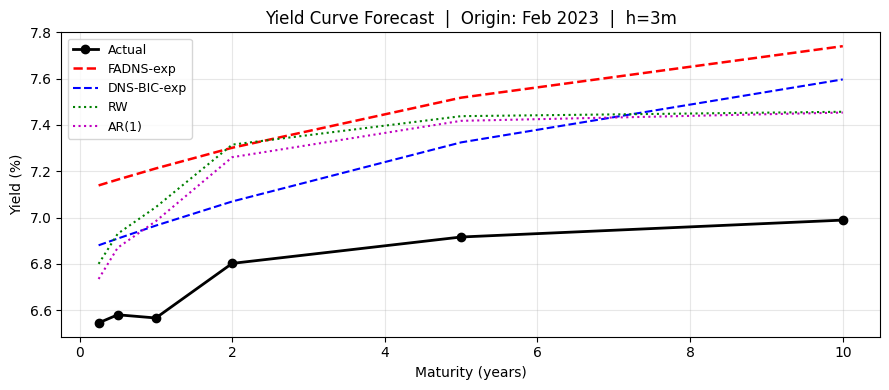

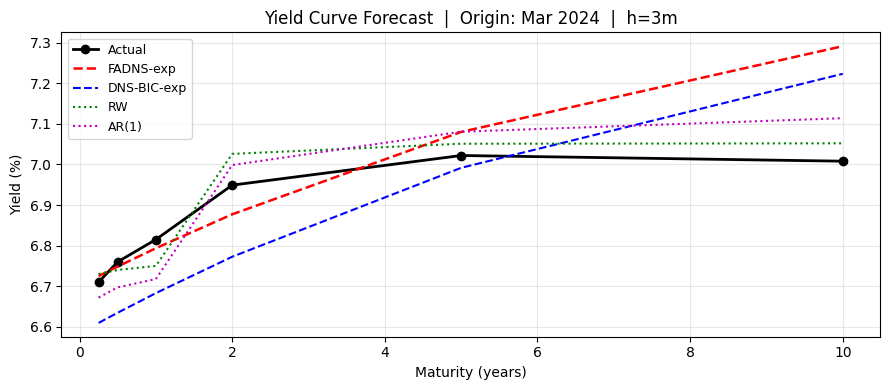

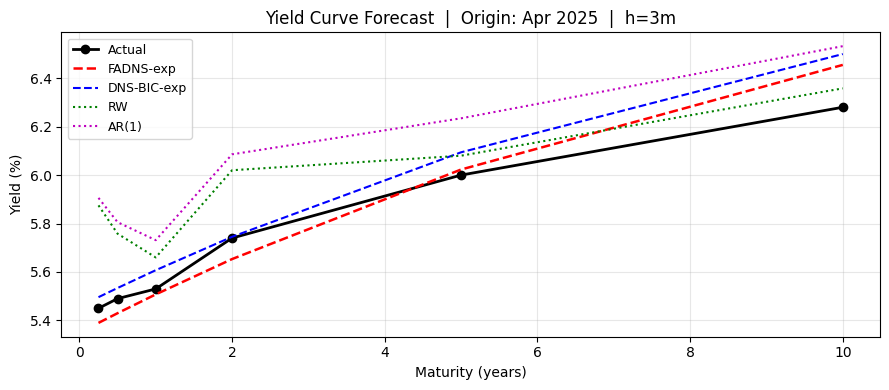

C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no

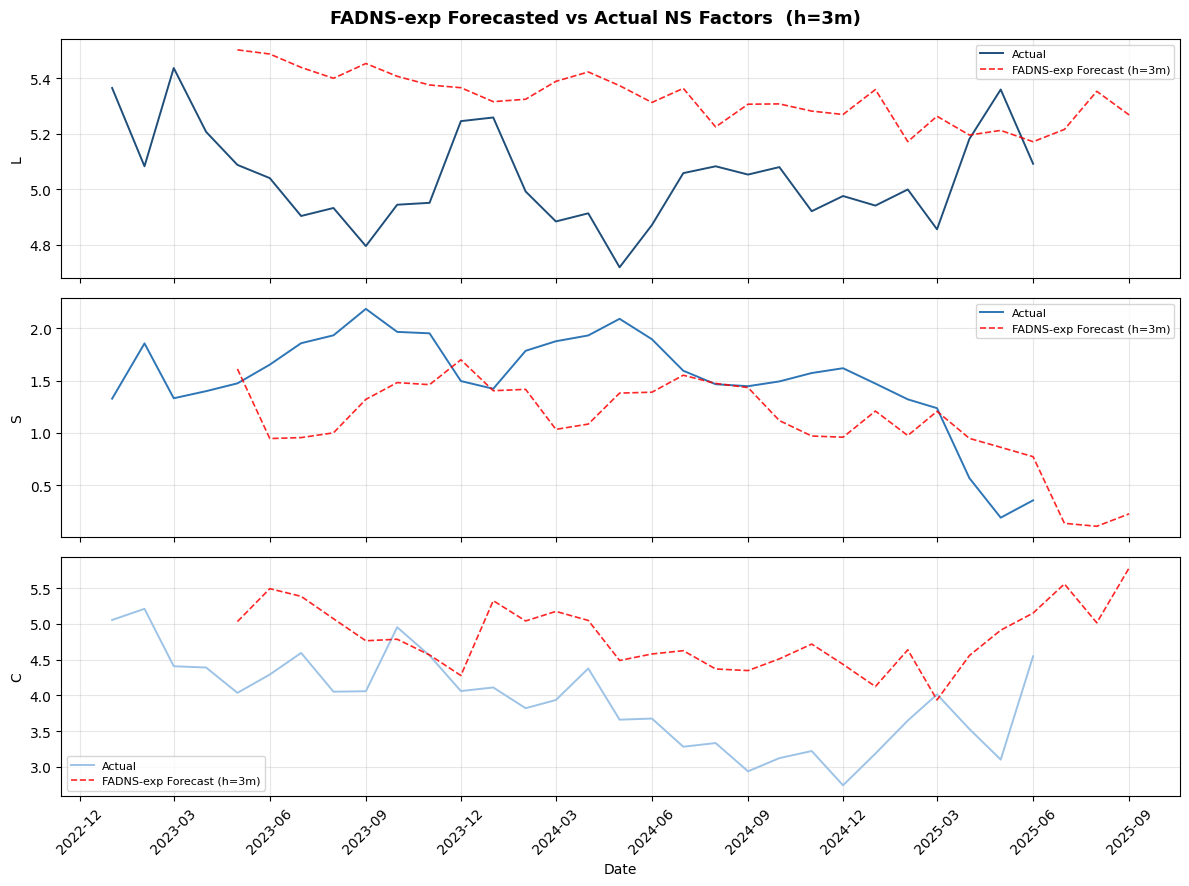


✅  Forecasting & evaluation complete.
    Static : dns_forecasts, fadns_forecasts
    Expand : dns_forecasts_exp, dns_forecasts_aic_exp, fadns_forecasts_exp
    Bench  : rw_forecasts, ar_forecasts   |   actual_h[h]


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 12 — FORECAST VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 10: Forecast visualisations")
print("=" * 60)

h_plot = 3
common = fadns_forecasts_exp[h_plot].index.intersection(actual_h[h_plot].index)
sample = [common[0], common[len(common)//2], common[-1]]

for dt in sample:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mats_array, actual_h[h_plot].loc[dt].values, "ko-", linewidth=2,
            markersize=6, label="Actual")
    ax.plot(mats_array, fadns_forecasts_exp[h_plot].loc[dt].values, "r--",
            linewidth=1.8, label="FADNS-exp")
    ax.plot(mats_array, dns_forecasts_exp[h_plot].loc[dt].values, "b--",
            linewidth=1.5, label="DNS-BIC-exp")
    ax.plot(mats_array, rw_forecasts[h_plot].loc[dt].values, "g:",
            linewidth=1.5, label="RW")
    ax.plot(mats_array, ar_forecasts[h_plot].loc[dt].values, "m:",
            linewidth=1.5, label="AR(1)")
    ax.set_title(f"Yield Curve Forecast  |  Origin: {pd.Timestamp(dt).strftime('%b %Y')}  |  h={h_plot}m")
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# ── FADNS-exp forecasted L, S, C vs actual (index shifted to t+h) ────────────
fadns_factors_fcast = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        pos = state_all.index.get_loc(t_date)
        window = state_all.iloc[:pos + 1]
        if len(window) < fadns_best_lag + 3:
            continue
        try:
            res  = VAR(window).fit(maxlags=fadns_best_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)[h - 1]
        except Exception:
            continue
        fadns_factors_fcast[h][t_date] = {"PC1": fc[0], "PC2": fc[1],
                                          "L": fc[2], "S": fc[3], "C": fc[4]}
    fadns_factors_fcast[h] = pd.DataFrame(fadns_factors_fcast[h]).T

h_plot = 3
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"FADNS-exp Forecasted vs Actual NS Factors  (h={h_plot}m)",
             fontsize=13, fontweight="bold")
for ax, col, color in zip(axes, ["L", "S", "C"], ["#1F4E79", "#2E75B6", "#9DC3E6"]):
    ax.plot(factors_test.index, factors_test[col], color=color, linewidth=1.4, label="Actual")
    fcast_col = fadns_factors_fcast[h_plot][col].copy()
    fcast_col.index = fcast_col.index + pd.DateOffset(months=h_plot)  # plot at predicted date
    ax.plot(fcast_col.index, fcast_col.values, color="red", linewidth=1.2,
            linestyle="--", alpha=0.85, label=f"FADNS-exp Forecast (h={h_plot}m)")
    ax.set_ylabel(col, fontsize=10); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("\n✅  Forecasting & evaluation complete.")
print("    Static : dns_forecasts, fadns_forecasts")
print("    Expand : dns_forecasts_exp, dns_forecasts_aic_exp, fadns_forecasts_exp")
print("    Bench  : rw_forecasts, ar_forecasts   |   actual_h[h]")


  STEP 11: LSTM forecasts (DNS-LSTM, FADNS-LSTM)

  Training DNS-LSTM...
  DNS-LSTM h= 3: trained on 166 seqs, forecast 30 origins.
  DNS-LSTM h= 6: trained on 163 seqs, forecast 30 origins.
  DNS-LSTM h=12: trained on 157 seqs, forecast 30 origins.

  Training FADNS-LSTM...
  FADNS-LSTM h= 3: trained on 165 seqs, forecast 29 origins.
  FADNS-LSTM h= 6: trained on 162 seqs, forecast 29 origins.
  FADNS-LSTM h=12: trained on 156 seqs, forecast 29 origins.

  STEP 12: LSTM vs VAR — RMSE comparison

───────────────────────────────────────────────────────
  Horizon h = 3 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.2869  0.2795       0.2334     0.2666    0.7023      0.7275
0.5Y   0.2913  0.2860       0.2593     0.2927    0.7361      0.7637
1.0Y   0.3259  0.3211       0.3018     0.3345    0.7757      0.8281
2.0Y   0.3230  0.3234       0.2979     0.2964    0.6457      0.7079
5.0

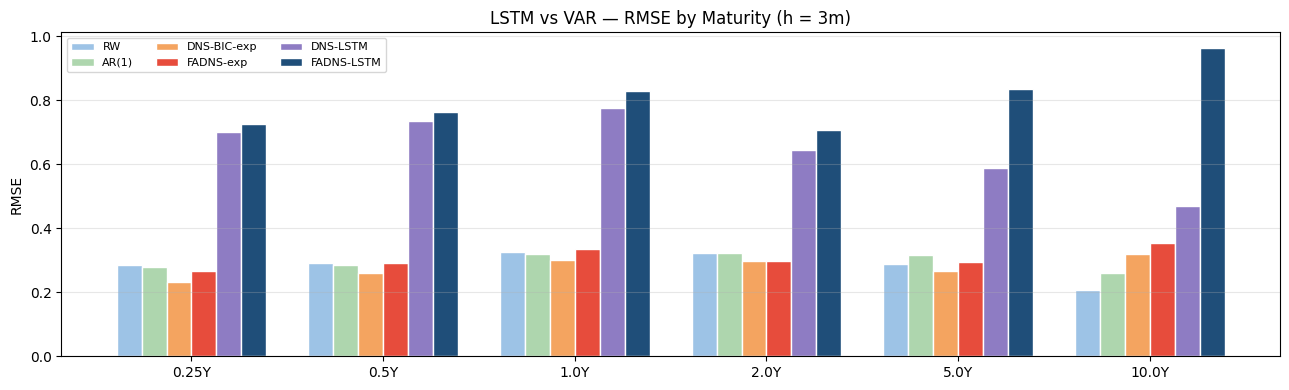


───────────────────────────────────────────────────────
  Horizon h = 6 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.4368  0.4049       0.3211     0.3531    0.6529      0.8102
0.5Y   0.4284  0.4037       0.3205     0.3709    0.6613      0.7948
1.0Y   0.4330  0.4158       0.3373     0.4073    0.6615      0.7711
2.0Y   0.4362  0.4270       0.3690     0.3946    0.6920      0.8286
5.0Y   0.3742  0.4349       0.3436     0.3987    0.5442      0.7106
10.0Y  0.2799  0.3833       0.4699     0.5156    0.4125      0.6797


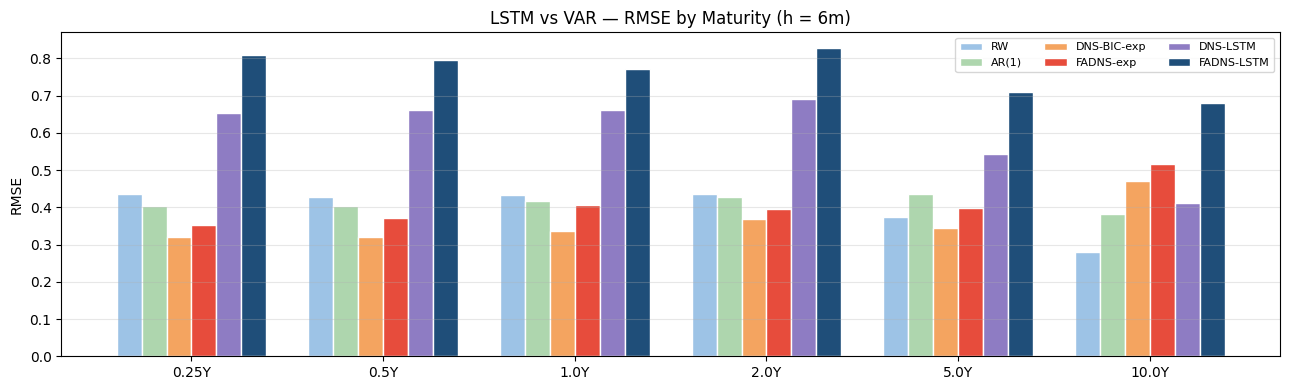


───────────────────────────────────────────────────────
  Horizon h = 12 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.5736  0.4746       0.4365     0.4692    1.0356      0.6633
0.5Y   0.6199  0.5234       0.4490     0.4886    1.0635      0.6770
1.0Y   0.6765  0.5817       0.4840     0.5301    1.0931      0.6867
2.0Y   0.6675  0.5905       0.4519     0.4857    0.9719      0.6700
5.0Y   0.6121  0.6678       0.5332     0.5796    0.8862      0.6235
10.0Y  0.4786  0.6127       0.7394     0.7767    0.7965      0.5832


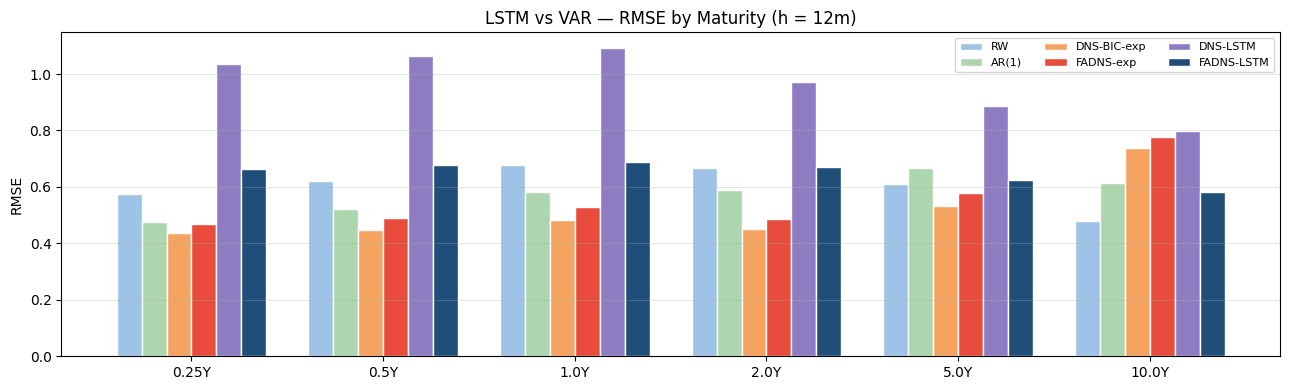


  SUMMARY — Average RMSE across maturities (lower = better)
                h=3     h=6    h=12
RW           0.2871  0.3981  0.6047
AR(1)        0.2977  0.4116  0.5751
DNS-BIC-exp  0.2797  0.3602  0.5157
FADNS-exp    0.3066  0.4067  0.5550
DNS-LSTM     0.6531  0.6041  0.9745
FADNS-LSTM   0.8047  0.7658  0.6506

  LSTM vs its linear VAR counterpart (avg RMSE; +ve Δ → VAR better):
    h= 3m  DNS:  LSTM=0.6531 vs VAR=0.2797  → VAR ✅
           FADNS: LSTM=0.8046 vs VAR=0.3066  → VAR ✅
    h= 6m  DNS:  LSTM=0.6041 vs VAR=0.3602  → VAR ✅
           FADNS: LSTM=0.7659 vs VAR=0.4067  → VAR ✅
    h=12m  DNS:  LSTM=0.9745 vs VAR=0.5157  → VAR ✅
           FADNS: LSTM=0.6506 vs VAR=0.5550  → VAR ✅


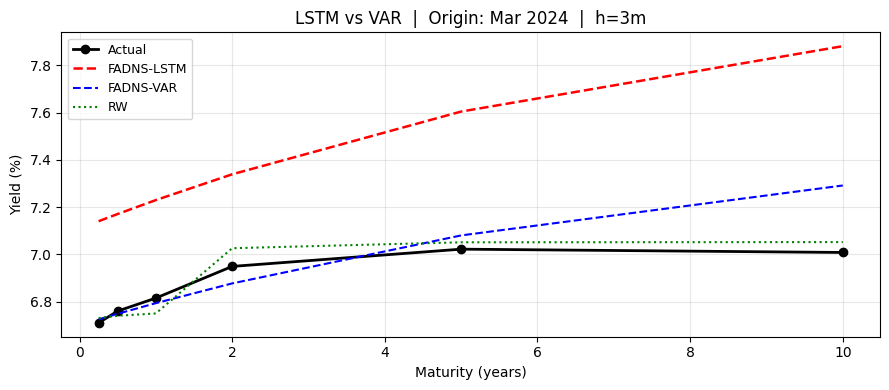


✅  LSTM evaluation complete.
    dns_lstm_forecasts, fadns_lstm_forecasts available per horizon.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 13 — LSTM FORECASTS  (neural alternative to the VAR dynamics)
#
#  WHERE THIS GOES
#  ---------------
#  Paste at the END of the pipeline, after Section 11 (so actual_h, compute_metrics,
#  reconstruct_curve, factors_train/test/all, state_train/test_common/all,
#  HORIZONS, MAX_H, mats_array all exist).
#
#  IDEA
#  ----
#  DNS/FADNS use a LINEAR VAR to map past factors → future factors. Here we swap
#  that single block for an LSTM and keep EVERYTHING else identical:
#     • same NS factors as features/targets
#     • same horizons h ∈ {3,6,12}
#     • same curve reconstruction (ŷ = L̂ + Ŝ·B1 + Ĉ·B2)
#     • same actual_h targets and the same RMSE/MAE scoring
#  So any RMSE difference is attributable to LINEAR-VAR vs LSTM, nothing else.
#
#  TWO MODELS (mirroring the VAR pair):
#     DNS-LSTM    features = [L, S, C]            → predict [L,S,C] at t+h
#     FADNS-LSTM  features = [PC1, PC2, L, S, C]  → predict [L,S,C] at t+h
#  One LSTM is trained PER HORIZON (direct multi-horizon forecasting).
#
#  HONEST CAVEAT
#  -------------
#  ~178 monthly training rows is extremely small for an LSTM. The net is kept
#  tiny (1 layer, 16 hidden units, dropout, weight decay) to limit overfitting,
#  but do not be surprised if it loses to RW/VAR — that is itself a valid result
#  for a small macro-finance sample. Scheme is STATIC (train once on train,
#  forecast across test) to match the static VAR and stay tractable; an expanding
#  LSTM is possible but means retraining ~40×3 nets.
#
#  REQUIRES: torch  (pip install torch)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 11: LSTM forecasts (DNS-LSTM, FADNS-LSTM)")
print("=" * 60)

try:
    import torch
    import torch.nn as nn
except ImportError:
    raise SystemExit("PyTorch not installed. Run:  pip install torch")

from sklearn.preprocessing import StandardScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyperparameters (tune these) ─────────────────────────────────────────────
LOOKBACK   = 12      # months of history fed to the LSTM (1 year)
HIDDEN     = 16      # LSTM hidden units (small on purpose)
EPOCHS     = 400
LR         = 5e-3
WEIGHT_DEC = 1e-4    # L2 regularisation
DROPOUT    = 0.10
TARGET_COLS = ["L", "S", "C"]


class TinyLSTM(nn.Module):
    """1-layer LSTM → linear head. Predicts the 3 NS factors at horizon h."""
    def __init__(self, n_feat, hidden=HIDDEN, n_out=3, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, n_out)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        last   = out[:, -1, :]         # last timestep
        return self.head(self.drop(last))


def build_sequences(feat_scaled, tgt_scaled, end_positions, lookback, h):
    """
    For each end position i (the forecast origin), build:
      X = feat_scaled[i-lookback+1 : i+1]   (lookback × n_feat)
      y = tgt_scaled[i+h]                   (target factors h steps ahead)
    Only positions with a valid history AND a known target (i+h in range) are used.
    """
    X, y, origins = [], [], []
    n = len(feat_scaled)
    for i in end_positions:
        if i - lookback + 1 < 0 or i + h >= n:
            continue
        X.append(feat_scaled[i - lookback + 1: i + 1])
        y.append(tgt_scaled[i + h])
        origins.append(i)
    if not X:
        return None, None, None
    return (np.asarray(X, dtype=np.float32),
            np.asarray(y, dtype=np.float32),
            origins)


def lstm_forecasts(feat_full_df, origin_dates, train_last_date, label):
    """
    Static LSTM forecasting, one model per horizon.

    feat_full_df    : DataFrame (train+test) with feature columns; MUST include
                      TARGET_COLS among its columns.
    origin_dates    : test origin dates to forecast FROM (same set the VAR used)
    train_last_date : last training date — sequences whose TARGET falls after this
                      are excluded from training (no look-ahead).

    Returns dict: h -> DataFrame (origins × maturities) of forecasted yields.
    """
    feat_cols = list(feat_full_df.columns)
    feat_full = feat_full_df.values.astype(np.float32)
    tgt_idx   = [feat_cols.index(c) for c in TARGET_COLS]

    # position of the last training date in the full frame
    train_last_pos = feat_full_df.index.get_loc(train_last_date)
    # training origins: any i whose history fits and whose target i+h ≤ train end
    train_positions = list(range(len(feat_full_df)))

    out = {h: {} for h in HORIZONS}

    for h in HORIZONS:
        # ----- scalers fit on TRAIN rows only (no leakage) -----
        train_rows = feat_full[:train_last_pos + 1]
        fscaler = StandardScaler().fit(train_rows)
        tscaler = StandardScaler().fit(train_rows[:, tgt_idx])

        feat_scaled = fscaler.transform(feat_full)
        tgt_scaled  = tscaler.transform(feat_full[:, tgt_idx])

        # training sequences: target date must be ≤ train_last_date
        train_ends = [i for i in train_positions if i + h <= train_last_pos]
        Xtr, ytr, _ = build_sequences(feat_scaled, tgt_scaled, train_ends, LOOKBACK, h)
        if Xtr is None or len(Xtr) < 20:
            print(f"  {label} h={h}: too few training sequences ({0 if Xtr is None else len(Xtr)}), skipped.")
            out[h] = pd.DataFrame(index=mats_array).T
            out[h].index.name = "Date"
            continue

        Xtr_t = torch.tensor(Xtr)
        ytr_t = torch.tensor(ytr)

        # ----- train -----
        torch.manual_seed(SEED)
        model = TinyLSTM(n_feat=Xtr.shape[2])
        opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DEC)
        lossf = nn.MSELoss()
        model.train()
        for ep in range(EPOCHS):
            opt.zero_grad()
            pred = model(Xtr_t)
            loss = lossf(pred, ytr_t)
            loss.backward()
            opt.step()

        # ----- forecast each test origin -----
        model.eval()
        with torch.no_grad():
            for t_date in origin_dates:
                try:
                    pos = feat_full_df.index.get_loc(t_date)
                except KeyError:
                    continue
                if pos - LOOKBACK + 1 < 0:
                    continue
                seq = feat_scaled[pos - LOOKBACK + 1: pos + 1]
                seq_t = torch.tensor(seq[np.newaxis, :, :].astype(np.float32))
                yhat_scaled = model(seq_t).numpy().ravel()
                L_h, S_h, C_h = tscaler.inverse_transform(yhat_scaled[np.newaxis, :]).ravel()
                out[h][t_date] = reconstruct_curve(L_h, S_h, C_h)

        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
        print(f"  {label} h={h:2d}: trained on {len(Xtr)} seqs, "
              f"forecast {out[h].shape[0]} origins.")

    return out


# ── Build full feature frames (train+test), aligned like the VAR inputs ──────
# DNS-LSTM features = [L, S, C]
dns_feat_full = factors_all[["L", "S", "C"]].copy()
# FADNS-LSTM features = [PC1, PC2, L, S, C]
fadns_feat_full = state_all[["PC1", "PC2", "L", "S", "C"]].copy()

train_last_date_dns   = factors_train.index[-1]
train_last_date_fadns = state_train.index[-1]

print("\n  Training DNS-LSTM...")
dns_lstm_forecasts = lstm_forecasts(
    dns_feat_full, factors_test.index, train_last_date_dns, label="DNS-LSTM")

print("\n  Training FADNS-LSTM...")
fadns_lstm_forecasts = lstm_forecasts(
    fadns_feat_full, state_test_common.index, train_last_date_fadns, label="FADNS-LSTM")


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 14 — LSTM vs VAR EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 12: LSTM vs VAR — RMSE comparison")
print("=" * 60)

# Add the two LSTM models to the comparison set (VAR models already exist)
eval_models = {
    "RW"          : rw_forecasts,
    "AR(1)"       : ar_forecasts,
    "DNS-BIC-exp" : dns_forecasts_exp,
    "FADNS-exp"   : fadns_forecasts_exp,
    "DNS-LSTM"    : dns_lstm_forecasts,
    "FADNS-LSTM"  : fadns_lstm_forecasts,
}

mat_labels = [f"{m}Y" for m in mats_array]
lstm_avg_summary = {}

bar_colors2 = ["#9DC3E6", "#AED6AE", "#F4A460", "#E74C3C", "#8E7CC3", "#1F4E79"]

for h in HORIZONS:
    print(f"\n{'─'*55}\n  Horizon h = {h} months — RMSE by maturity\n{'─'*55}")
    rmse_table = {}
    for name, fc in eval_models.items():
        rmse, _ = compute_metrics(fc[h], actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
    rmse_df = pd.DataFrame(rmse_table, index=mat_labels).round(4)
    print(rmse_df.to_string())
    lstm_avg_summary[f"h={h}"] = rmse_df.mean().round(4)

    x, width = np.arange(len(mat_labels)), 0.13
    fig, ax = plt.subplots(figsize=(13, 4))
    for i, (name, color) in enumerate(zip(rmse_table.keys(), bar_colors2)):
        ax.bar(x + i * width, rmse_table[name], width, label=name,
               color=color, edgecolor="white")
    ax.set_xticks(x + width * (len(rmse_table) - 1) / 2)
    ax.set_xticklabels(mat_labels)
    ax.set_ylabel("RMSE"); ax.set_title(f"LSTM vs VAR — RMSE by Maturity (h = {h}m)")
    ax.legend(ncol=3, fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("  SUMMARY — Average RMSE across maturities (lower = better)")
print("=" * 60)
print(pd.DataFrame(lstm_avg_summary).to_string())

print("\n  LSTM vs its linear VAR counterpart (avg RMSE; +ve Δ → VAR better):")
def a_rmse2(fc_dict, h):
    rmse, _ = compute_metrics(fc_dict[h], actual_h[h])
    return np.nan if rmse is None else float(np.mean(rmse))

for h in HORIZONS:
    d_dns   = a_rmse2(dns_lstm_forecasts, h)   - a_rmse2(dns_forecasts_exp, h)
    d_fadns = a_rmse2(fadns_lstm_forecasts, h) - a_rmse2(fadns_forecasts_exp, h)
    print(f"    h={h:2d}m  DNS:  LSTM={a_rmse2(dns_lstm_forecasts,h):.4f} vs "
          f"VAR={a_rmse2(dns_forecasts_exp,h):.4f}  → "
          f"{'VAR ✅' if d_dns>0 else 'LSTM ✅'}")
    print(f"           FADNS: LSTM={a_rmse2(fadns_lstm_forecasts,h):.4f} vs "
          f"VAR={a_rmse2(fadns_forecasts_exp,h):.4f}  → "
          f"{'VAR ✅' if d_fadns>0 else 'LSTM ✅'}")

# ── Sample curve: LSTM vs VAR vs actual at one origin (h=3) ───────────────────
h_plot = 3
common = (dns_lstm_forecasts[h_plot].index
          .intersection(actual_h[h_plot].index)
          .intersection(fadns_lstm_forecasts[h_plot].index))
if len(common):
    dt = common[len(common) // 2]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mats_array, actual_h[h_plot].loc[dt].values, "ko-", linewidth=2,
            markersize=6, label="Actual")
    ax.plot(mats_array, fadns_lstm_forecasts[h_plot].loc[dt].values, "r--",
            linewidth=1.8, label="FADNS-LSTM")
    ax.plot(mats_array, fadns_forecasts_exp[h_plot].loc[dt].values, "b--",
            linewidth=1.5, label="FADNS-VAR")
    ax.plot(mats_array, rw_forecasts[h_plot].loc[dt].values, "g:",
            linewidth=1.5, label="RW")
    ax.set_title(f"LSTM vs VAR  |  Origin: {pd.Timestamp(dt).strftime('%b %Y')}  |  h={h_plot}m")
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print("\n✅  LSTM evaluation complete.")
print("    dns_lstm_forecasts, fadns_lstm_forecasts available per horizon.")


  STEP 10b: DNS expanding vs static — factor-level plots


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmod

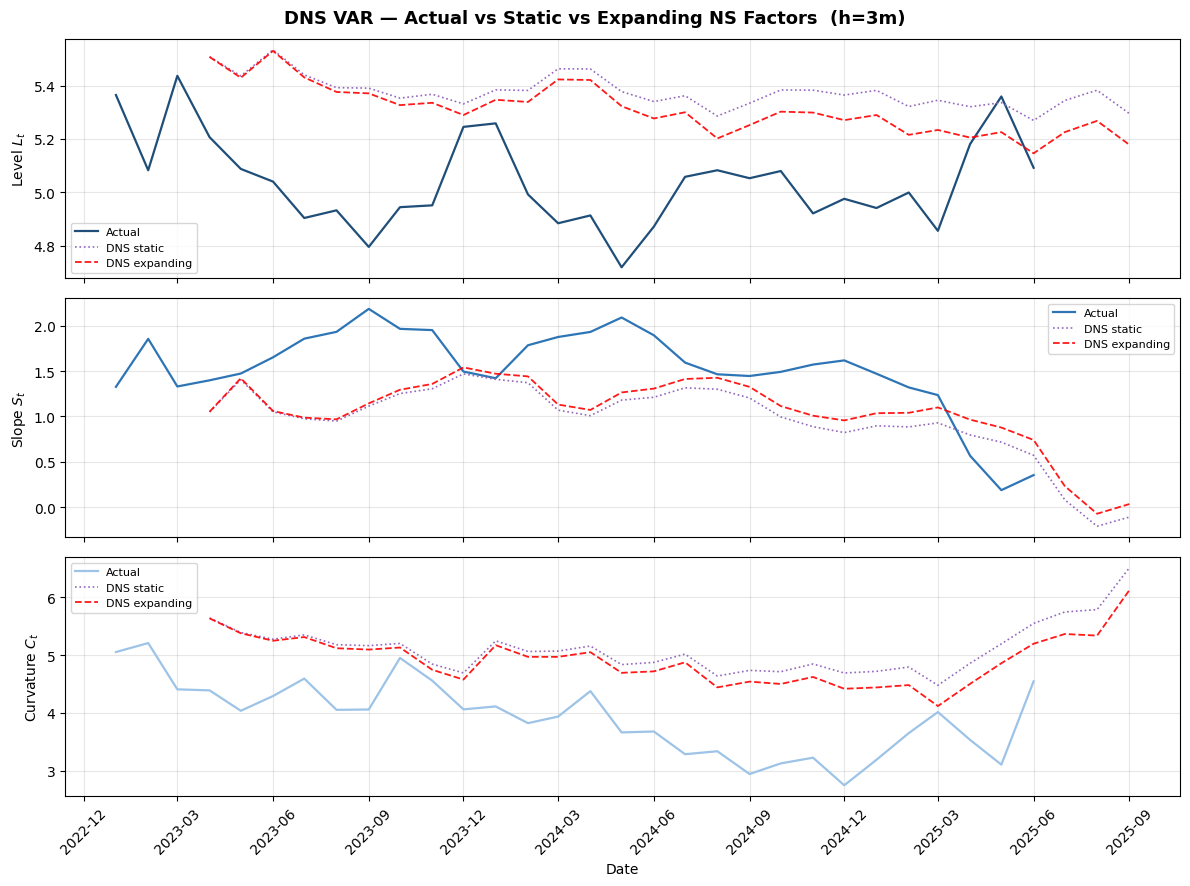


  Mean signed forecast error (forecast − actual) at h=3m:
  factor     static    expanding
  L          0.3669       0.3083   (bias shrinks ✅)
  S         -0.4479      -0.3598   (bias shrinks ✅)
  C          1.1853       1.0217   (bias shrinks ✅)


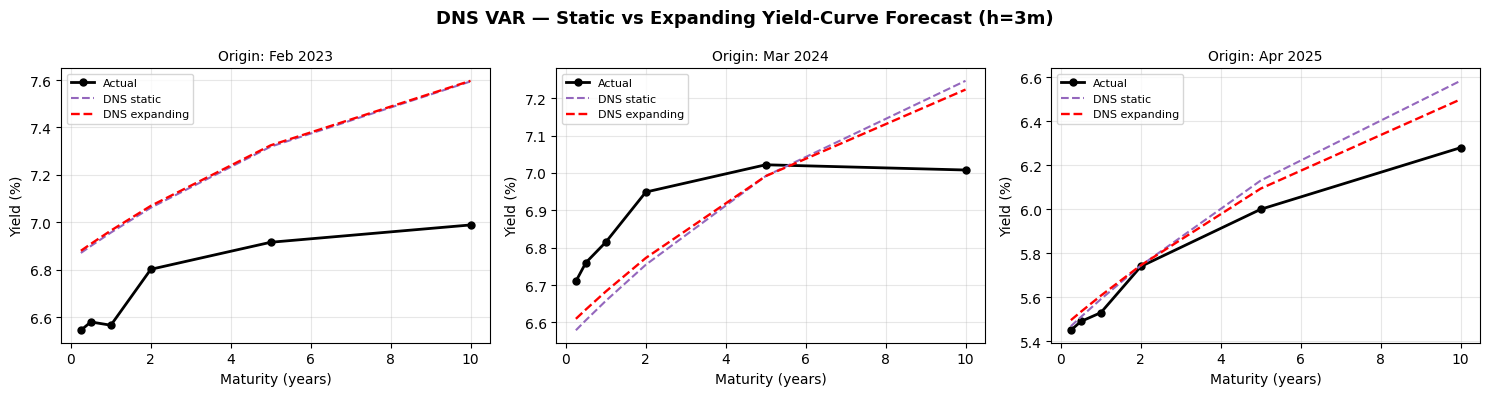


✅  DNS expanding-window plots done.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 12b — PLOT: DNS EXPANDING-WINDOW VAR  (factor level + curve snapshots)
#
#  Paste after Section 12. Reuses: factors_all, factors_test, var_result,
#  best_lag, VAR, HORIZONS, MAX_H, mats_array, reconstruct_curve, actual_h,
#  dns_forecasts, dns_forecasts_exp, rw_forecasts, factor_colors/labels.
#
#  Purpose: the earlier static plot showed a parallel shift (forecasts pulled to
#  the 2008–2022 mean). This recomputes the DNS forecasts at the FACTOR level for
#  both schemes and overlays them on the actual factors, with the forecast index
#  shifted to t+h (the date each forecast actually predicts), so you can see
#  whether the expanding window pulls the dashed line back toward the actual.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 10b: DNS expanding vs static — factor-level plots")
print("=" * 60)

H_PLOT = 3   # horizon to visualise (3, 6 or 12)

# ── 1) DNS EXPANDING factor forecasts (refit VAR at each origin) ─────────────
dns_factors_exp = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in factors_test.index:
        pos    = factors_all.index.get_loc(t_date)
        window = factors_all.iloc[:pos + 1]            # data up to & incl. t (no look-ahead)
        if len(window) < best_lag + 3:
            continue
        try:
            res  = VAR(window).fit(maxlags=best_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)[h - 1]   # (L, S, C) at t+h
        except Exception:
            continue
        dns_factors_exp[h][t_date] = {"L": fc[0], "S": fc[1], "C": fc[2]}
    dns_factors_exp[h] = pd.DataFrame(dns_factors_exp[h]).T

# ── 2) DNS STATIC factor forecasts (one train fit, var_result) ───────────────
dns_factors_static = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in factors_test.index:
        pos = factors_all.index.get_loc(t_date)
        if pos < best_lag:
            continue
        init = factors_all.iloc[pos - best_lag + 1: pos + 1].values
        fc   = var_result.forecast(init, steps=MAX_H)[h - 1]
        dns_factors_static[h][t_date] = {"L": fc[0], "S": fc[1], "C": fc[2]}
    dns_factors_static[h] = pd.DataFrame(dns_factors_static[h]).T

# ── 3) Plot: actual vs DNS-static vs DNS-expanding (index shifted to t+h) ─────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"DNS VAR — Actual vs Static vs Expanding NS Factors  (h={H_PLOT}m)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["L", "S", "C"]):
    # actual factors over the test period
    ax.plot(factors_test.index, factors_test[col],
            color=factor_colors[col], linewidth=1.6, label="Actual")

    # static forecast — shift index to the date it predicts (t+h)
    s = dns_factors_static[H_PLOT][col].copy()
    s.index = s.index + pd.DateOffset(months=H_PLOT)
    ax.plot(s.index, s.values, color="#9467BD", linewidth=1.2,
            linestyle=":", label="DNS static")

    # expanding forecast — same shift
    e = dns_factors_exp[H_PLOT][col].copy()
    e.index = e.index + pd.DateOffset(months=H_PLOT)
    ax.plot(e.index, e.values, color="red", linewidth=1.3,
            linestyle="--", alpha=0.9, label="DNS expanding")

    ax.set_ylabel(factor_labels[col], fontsize=10)
    ax.legend(fontsize=8, loc="best"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ── 4) Quantify the parallel shift: mean signed error (bias) per factor ──────
print(f"\n  Mean signed forecast error (forecast − actual) at h={H_PLOT}m:")
print(f"  {'factor':6s} {'static':>10} {'expanding':>12}")
for col in ["L", "S", "C"]:
    a = factors_test[col]
    bias_s, bias_e = [], []
    for src, store in [(dns_factors_static[H_PLOT][col], bias_s),
                       (dns_factors_exp[H_PLOT][col],    bias_e)]:
        for t_date, val in src.items():
            tgt = t_date + pd.DateOffset(months=H_PLOT)
            if tgt in a.index:
                store.append(val - a.loc[tgt])
    ms = np.nanmean(bias_s) if bias_s else np.nan
    me = np.nanmean(bias_e) if bias_e else np.nan
    print(f"  {col:6s} {ms:>10.4f} {me:>12.4f}   "
          f"{'(bias shrinks ✅)' if abs(me) < abs(ms) else '(no improvement)'}")

# ── 5) Yield-curve snapshots: DNS expanding vs static vs actual (h=3) ─────────
common = (dns_forecasts_exp[H_PLOT].index
          .intersection(actual_h[H_PLOT].index)
          .intersection(dns_forecasts[H_PLOT].index))
if len(common):
    sample = [common[0], common[len(common)//2], common[-1]]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"DNS VAR — Static vs Expanding Yield-Curve Forecast (h={H_PLOT}m)",
                 fontsize=13, fontweight="bold")
    for ax, dt in zip(axes, sample):
        ax.plot(mats_array, actual_h[H_PLOT].loc[dt].values, "ko-",
                linewidth=2, markersize=5, label="Actual")
        ax.plot(mats_array, dns_forecasts[H_PLOT].loc[dt].values, "--",
                color="#9467BD", linewidth=1.5, label="DNS static")
        ax.plot(mats_array, dns_forecasts_exp[H_PLOT].loc[dt].values, "r--",
                linewidth=1.7, label="DNS expanding")
        ax.set_title(f"Origin: {pd.Timestamp(dt).strftime('%b %Y')}", fontsize=10)
        ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print("\n✅  DNS expanding-window plots done.")

In [18]:
print("\nOrigin-date overlap check (this should be identical across all models):")
for h in HORIZONS:
    idx_rw    = rw_forecasts[h].index
    idx_dns   = dns_forecasts_exp[h].index
    idx_fadns = fadns_forecasts_exp[h].index
    idx_act   = actual_h[h].index
    print(f"  h={h:2d}: RW={len(idx_rw)}, DNS-exp={len(idx_dns)}, "
          f"FADNS-exp={len(idx_fadns)}, actual={len(idx_act)}")
    common_all = idx_rw.intersection(idx_dns).intersection(idx_fadns).intersection(idx_act)
    print(f"        common to ALL four: {len(common_all)}")


Origin-date overlap check (this should be identical across all models):
  h= 3: RW=29, DNS-exp=30, FADNS-exp=29, actual=27
        common to ALL four: 27
  h= 6: RW=29, DNS-exp=30, FADNS-exp=29, actual=24
        common to ALL four: 24
  h=12: RW=29, DNS-exp=30, FADNS-exp=29, actual=18
        common to ALL four: 18


In [19]:
print("Per-date RMSE breakdown (averaged across maturities), RW vs FADNS-exp vs DNS-exp:")
for h in HORIZONS:
    common = (rw_forecasts[h].index
              .intersection(dns_forecasts_exp[h].index)
              .intersection(fadns_forecasts_exp[h].index)
              .intersection(actual_h[h].index))
    print(f"\n  h={h} months, n={len(common)} common origin dates")
    rows = []
    for t in common:
        a   = actual_h[h].loc[t].values.astype(float)
        rw  = rw_forecasts[h].loc[t].values.astype(float)
        dns = dns_forecasts_exp[h].loc[t].values.astype(float)
        fa  = fadns_forecasts_exp[h].loc[t].values.astype(float)
        rows.append({
            "date": t.date(),
            "RW_err":    np.sqrt(np.mean((rw - a)**2)),
            "DNSexp_err":np.sqrt(np.mean((dns - a)**2)),
            "FADNSexp_err": np.sqrt(np.mean((fa - a)**2)),
        })
    diag = pd.DataFrame(rows).set_index("date")
    print(diag.round(4).to_string())
    print("\n  Mean:", diag.mean().round(4).to_dict())
    print("  How many dates does each model beat RW on?")
    print("   DNS-exp beats RW:  ", (diag["DNSexp_err"] < diag["RW_err"]).sum(), "/", len(diag))
    print("   FADNS-exp beats RW:", (diag["FADNSexp_err"] < diag["RW_err"]).sum(), "/", len(diag))

Per-date RMSE breakdown (averaged across maturities), RW vs FADNS-exp vs DNS-exp:

  h=3 months, n=27 common origin dates
            RW_err  DNSexp_err  FADNSexp_err
date                                        
2023-02-01  0.4419      0.4058        0.6174
2023-03-01  0.1182      0.1308        0.1917
2023-04-01  0.1539      0.2693        0.2865
2023-05-01  0.2764      0.4022        0.3564
2023-06-01  0.2433      0.3587        0.1808
2023-07-01  0.1741      0.2631        0.1311
2023-08-01  0.1105      0.1950        0.1236
2023-09-01  0.2321      0.1695        0.3417
2023-10-01  0.2614      0.2404        0.1791
2023-11-01  0.1764      0.1723        0.1570
2023-12-01  0.0798      0.1683        0.2491
2024-01-01  0.1633      0.2747        0.2643
2024-02-01  0.0604      0.1721        0.1451
2024-03-01  0.0478      0.1424        0.1223
2024-04-01  0.2580      0.2295        0.3761
2024-05-01  0.2461      0.1904        0.2407
2024-06-01  0.3005      0.2499        0.3649
2024-07-01  0.0894     

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11b — DIEBOLD-MARIANO TEST  (RW vs DNS-exp vs FADNS-exp, per horizon)
#
#  Tests whether the difference in forecast accuracy between two models is
#  statistically distinguishable from zero, rather than just comparing mean
#  RMSE on a handful of dates (18-27 obs here, far too few to trust a raw
#  mean comparison). Uses the Harvey-Leybourne-Newbold small-sample correction,
#  recommended whenever n is this small, and a Newey-West variance estimate
#  truncated at lag h-1 (the standard DM choice for h-step-ahead forecasts).
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats


def diebold_mariano(d, h=1, harvey_correction=True):
    """
    Diebold-Mariano test on a pre-computed loss-differential series `d`.

    d_t = L(e1_t) - L(e2_t)   where e1, e2 are the two models' forecast errors
    at each origin date, and L is whatever loss you chose when building `d`
    (squared error, absolute error, etc. — already applied before this call).

    H0: E[d_t] = 0 (no difference in expected loss).
    A positive DM statistic means model 2 has lower loss (more accurate);
    negative means model 1 is more accurate.

    Returns (dm_stat, p_value). p_value uses a Student-t(n-1) reference
    distribution when harvey_correction=True (appropriate for small n),
    else a Normal reference.
    """
    d = np.asarray(d, dtype=float)
    n = len(d)
    d_bar = d.mean()

    # Newey-West (HAC) long-run variance, Bartlett kernel, truncated at h-1
    # (h-step-ahead forecast errors are autocorrelated up to lag h-1 under
    # the null of forecast optimality).
    max_lag = max(h - 1, 0)
    var_d = np.var(d, ddof=0)
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=0)[0, 1]
        var_d += 2 * (1 - lag / (max_lag + 1)) * cov

    var_d = max(var_d, 1e-12)
    dm_stat = d_bar / np.sqrt(var_d / n)

    if harvey_correction:
        correction = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
        dm_stat *= correction
        p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=n - 1))
    else:
        p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


def per_date_rmse(forecast_df, actual_df, common_idx):
    """RMSE across maturities, one scalar per origin date, restricted to common_idx."""
    f = forecast_df.loc[common_idx].values.astype(float)
    a = actual_df.loc[common_idx].values.astype(float)
    return np.sqrt(np.mean((f - a) ** 2, axis=1))


print("\n" + "=" * 70)
print("  DIEBOLD-MARIANO TEST — each model vs Random Walk (RW), per horizon")
print("  Loss = squared, on per-date RMSE-across-maturities series")
print("  (*** p<0.01, ** p<0.05, * p<0.10, blank = not significant)")
print("=" * 70)

dm_rows = []
for h in HORIZONS:
    rw_fc = rw_forecasts[h]
    act   = actual_h[h]

    for name, fc_dict in [("DNS-exp", dns_forecasts_exp),
                          ("FADNS-exp", fadns_forecasts_exp),
                          ("DNS-static", dns_forecasts),
                          ("FADNS-static", fadns_forecasts),
                          ("AR(1)", ar_forecasts)]:
        fc = fc_dict[h]
        common = rw_fc.index.intersection(fc.index).intersection(act.index)
        if len(common) < 5:
            dm_rows.append({"horizon": h, "model": name, "n": len(common),
                            "dm_stat": np.nan, "p_value": np.nan,
                            "verdict": "too few obs"})
            continue

        rw_rmse  = per_date_rmse(rw_fc, act, common)
        mod_rmse = per_date_rmse(fc,    act, common)

        # Loss differential: squared RMSE (= MSE per date) so the loss units
        # match what RMSE tables already report on. d>0 favors `name`.
        d = rw_rmse ** 2 - mod_rmse ** 2

        dm_stat, p_value = diebold_mariano(d, h=h, harvey_correction=True)

        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""

        if p_value < 0.10:
            verdict = f"{name} significantly better" if dm_stat > 0 else "RW significantly better"
        else:
            verdict = "no significant difference"

        dm_rows.append({
            "horizon": h, "model": name, "n": len(common),
            "rw_mean_rmse": round(rw_rmse.mean(), 4),
            "model_mean_rmse": round(mod_rmse.mean(), 4),
            "dm_stat": round(dm_stat, 4), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict
        })

dm_df = pd.DataFrame(dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(dm_df[dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 70)
print("  Reading the table: dm_stat > 0 means the named model beats RW;")
print("  dm_stat < 0 means RW beats the named model. Only trust the verdict")
print("  if sig is *, **, or *** — blank means the difference is statistically")
print("  indistinguishable from zero given how few test-period observations exist.")
print("=" * 70)


  DIEBOLD-MARIANO TEST — each model vs Random Walk (RW), per horizon
  Loss = squared, on per-date RMSE-across-maturities series
  (*** p<0.01, ** p<0.05, * p<0.10, blank = not significant)

--- Horizon h = 3 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_stat  p_value sig                   verdict
     DNS-exp 27        0.2363           0.2514   0.2810   0.7809     no significant difference
   FADNS-exp 27        0.2363           0.2722  -0.6033   0.5515     no significant difference
  DNS-static 27        0.2363           0.2586   0.1628   0.8719     no significant difference
FADNS-static 27        0.2363           0.2805  -0.8525   0.4017     no significant difference
       AR(1) 27        0.2363           0.2457  -0.9496   0.3511     no significant difference

--- Horizon h = 6 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_stat  p_value sig                   verdict
     DNS-exp 24        0.3212           0.3222   0.4394   0.6645     no significant 

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11b — DIEBOLD-MARIANO TEST  (RW vs DNS-exp vs FADNS-exp, per horizon)
#
#  Tests whether the difference in forecast accuracy between two models is
#  statistically distinguishable from zero, rather than just comparing mean
#  RMSE on a handful of dates (18-27 obs here, far too few to trust a raw
#  mean comparison). Uses the Harvey-Leybourne-Newbold small-sample correction,
#  recommended whenever n is this small, and a Newey-West variance estimate
#  truncated at lag h-1 (the standard DM choice for h-step-ahead forecasts).
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats


def diebold_mariano(d, h=1, harvey_correction=True):
    """
    Diebold-Mariano test on a pre-computed loss-differential series `d`.

    d_t = L(e1_t) - L(e2_t)   where e1, e2 are the two models' forecast errors
    at each origin date, and L is whatever loss you chose when building `d`
    (squared error here). H0: E[d_t] = 0 (no difference in expected loss).
    A positive DM statistic means model 2 (e2) has lower loss; negative means
    model 1 (e1) is more accurate.

    Uses the Harvey, Leybourne & Newbold (1997) small-sample correction by
    default — essential here since n is only 18-27. HLN rescales the raw DM
    statistic by sqrt((n+1-2h+h(h-1)/n)/n) and references it against a
    Student-t(n-1) distribution instead of Normal, which corrects for the
    over-confidence of the asymptotic test when the forecast horizon h is
    large relative to the sample size n (exactly the regime at h=12, n=18
    here, where the correction factor shrinks to ~0.36).

    Returns (dm_stat, p_value, dm_stat_raw, correction_factor) so both the
    raw and HLN-corrected versions can be reported side by side.
    """
    d = np.asarray(d, dtype=float)
    n = len(d)
    d_bar = d.mean()

    # Newey-West (HAC) long-run variance, Bartlett kernel, truncated at h-1
    # (h-step-ahead forecast errors are autocorrelated up to lag h-1 under
    # the null of forecast optimality).
    max_lag = max(h - 1, 0)
    var_d = np.var(d, ddof=0)
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=0)[0, 1]
        var_d += 2 * (1 - lag / (max_lag + 1)) * cov
    var_d = max(var_d, 1e-12)

    dm_stat_raw = d_bar / np.sqrt(var_d / n)

    if harvey_correction:
        correction = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
        dm_stat = dm_stat_raw * correction
        p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=n - 1))
    else:
        correction = 1.0
        dm_stat = dm_stat_raw
        p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value, dm_stat_raw, correction


def per_date_rmse(forecast_df, actual_df, common_idx):
    """RMSE across maturities, one scalar per origin date, restricted to common_idx."""
    f = forecast_df.loc[common_idx].values.astype(float)
    a = actual_df.loc[common_idx].values.astype(float)
    return np.sqrt(np.mean((f - a) ** 2, axis=1))


print("\n" + "=" * 90)
print("  DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold corrected) — each model vs RW")
print("  Loss = squared, on per-date RMSE-across-maturities series")
print("  HLN correction is essential here: n is only 18-27 observations,")
print("  and the correction factor shrinks sharply as h grows relative to n")
print("  (e.g. ~0.36 at h=12, n=18) — using uncorrected Normal p-values would")
print("  overstate significance at longer horizons.")
print("  (*** p<0.01, ** p<0.05, * p<0.10 on the HLN-corrected, t-referenced p-value)")
print("=" * 90)

dm_rows = []
for h in HORIZONS:
    rw_fc = rw_forecasts[h]
    act   = actual_h[h]

    for name, fc_dict in [("DNS-exp", dns_forecasts_exp),
                          ("FADNS-exp", fadns_forecasts_exp),
                          ("DNS-static", dns_forecasts),
                          ("FADNS-static", fadns_forecasts),
                          ("AR(1)", ar_forecasts)]:
        fc = fc_dict[h]
        common = rw_fc.index.intersection(fc.index).intersection(act.index)
        if len(common) < 5:
            dm_rows.append({"horizon": h, "model": name, "n": len(common),
                            "dm_raw": np.nan, "dm_hln": np.nan, "hln_corr": np.nan,
                            "p_value": np.nan, "verdict": "too few obs"})
            continue

        rw_rmse  = per_date_rmse(rw_fc, act, common)
        mod_rmse = per_date_rmse(fc,    act, common)

        # Loss differential: squared RMSE (= MSE per date) so the loss units
        # match what the RMSE tables already report. d>0 favors `name`.
        d = rw_rmse ** 2 - mod_rmse ** 2

        dm_hln, p_value, dm_raw, corr = diebold_mariano(d, h=h, harvey_correction=True)

        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""

        if p_value < 0.10:
            verdict = f"{name} sig. better" if dm_hln > 0 else "RW sig. better"
        else:
            verdict = "no significant difference"

        dm_rows.append({
            "horizon": h, "model": name, "n": len(common),
            "rw_mean_rmse": round(rw_rmse.mean(), 4),
            "model_mean_rmse": round(mod_rmse.mean(), 4),
            "dm_raw": round(dm_raw, 4), "dm_hln": round(dm_hln, 4),
            "hln_corr": round(corr, 3), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict
        })

dm_df = pd.DataFrame(dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(dm_df[dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 90)
print("  dm_hln > 0  -> named model beats RW   |   dm_hln < 0 -> RW beats named model")
print("  hln_corr shows how much HLN shrinks the raw statistic — small values")
print("  (e.g. <0.5) signal the asymptotic test would have been overconfident.")
print("  Only trust 'sig. better' verdicts when sig is *, **, or *** — blank means")
print("  the apparent gap is statistically indistinguishable from sampling noise.")
print("=" * 90)


  DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold corrected) — each model vs RW
  Loss = squared, on per-date RMSE-across-maturities series
  HLN correction is essential here: n is only 18-27 observations,
  and the correction factor shrinks sharply as h grows relative to n
  (e.g. ~0.36 at h=12, n=18) — using uncorrected Normal p-values would
  overstate significance at longer horizons.
  (*** p<0.01, ** p<0.05, * p<0.10 on the HLN-corrected, t-referenced p-value)

--- Horizon h = 3 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_raw  dm_hln  hln_corr  p_value sig                   verdict
     DNS-exp 27        0.2363           0.2514  0.3097  0.2810     0.907   0.7809     no significant difference
   FADNS-exp 27        0.2363           0.2722 -0.6650 -0.6033     0.907   0.5515     no significant difference
  DNS-static 27        0.2363           0.2586  0.1795  0.1628     0.907   0.8719     no significant difference
FADNS-static 27        0.2363           0.2805 -0.93